In [2]:
sjnr = '158136'#'154532'#'153732'#'149741'#'133019'#'102816'

In [5]:
import nibabel as nib
import numpy as np
import fast_simplification

def downsample_surface_fast(input_file, output_file, target_reduction=0.93):
    """
    Downsample surface using fast quadric mesh simplification.
    
    target_reduction: float between 0 and 1
        Fraction of faces to remove
        e.g., 0.93 removes 93% of faces (keeps 7% ≈ 20k faces from 300k)
    """
    print(f"\nProcessing {input_file}...")
    
    # Load GIFTI surface
    surf = nib.load(input_file)
    vertices = surf.darrays[0].data
    faces = surf.darrays[1].data
    print(f"Original: {len(vertices)} vertices, {len(faces)} faces")
    
    # Decimate using fast simplification
    print(f"  Target reduction: {target_reduction} ({(1-target_reduction)*100:.1f}% retained)")
    new_vertices, new_faces = fast_simplification.simplify(
        vertices, 
        faces, 
        target_reduction=target_reduction
    )
    
    print(f"Decimated: {len(new_vertices)} vertices, {len(new_faces)} faces")
    
    # Save as GIFTI
    vertex_array = nib.gifti.GiftiDataArray(
        data=new_vertices.astype(np.float32),
        intent='NIFTI_INTENT_POINTSET',
        datatype='NIFTI_TYPE_FLOAT32'
    )
    face_array = nib.gifti.GiftiDataArray(
        data=new_faces.astype(np.int32),
        intent='NIFTI_INTENT_TRIANGLE',
        datatype='NIFTI_TYPE_INT32'
    )
    
    new_surf = nib.gifti.GiftiImage(darrays=[vertex_array, face_array])
    nib.save(new_surf, output_file)
    print(f"Saved to {output_file}")
    
    return new_vertices, new_faces


# ==================== MAIN ====================
if __name__ == "__main__":
    # 0.93 reduction = keep 7% ≈ 20k faces (10k vertices) from typical 300k face mesh
    target_reduction = 0.92
    
    # Process both hemispheres
    lh_vertices, lh_faces = downsample_surface_fast(
        f"/Users/marcoaqil/Downloads/{sjnr}/T1w/Native/{sjnr}.L.midthickness.native.surf.gii",
        f"/Users/marcoaqil/Downloads/{sjnr}/T1w/Native/{sjnr}.L.midthickness.downsampled.surf.gii",
        target_reduction=target_reduction
    )
    
    rh_vertices, rh_faces = downsample_surface_fast(
        f"/Users/marcoaqil/Downloads/{sjnr}/T1w/Native/{sjnr}.R.midthickness.native.surf.gii",
        f"/Users/marcoaqil/Downloads/{sjnr}/T1w/Native/{sjnr}.R.midthickness.downsampled.surf.gii",
        target_reduction=target_reduction
    )

    # Process both hemispheres
    lh_vertices, lh_faces = downsample_surface_fast(
        f"/Users/marcoaqil/Downloads/{sjnr}/T1w/Native/{sjnr}.L.white.native.surf.gii",
        f"/Users/marcoaqil/Downloads/{sjnr}/T1w/Native/{sjnr}.L.white.downsampled.surf.gii",
        target_reduction=target_reduction
    )
    
    rh_vertices, rh_faces = downsample_surface_fast(
        f"/Users/marcoaqil/Downloads/{sjnr}/T1w/Native/{sjnr}.R.white.native.surf.gii",
        f"/Users/marcoaqil/Downloads/{sjnr}/T1w/Native/{sjnr}.R.white.downsampled.surf.gii",
        target_reduction=target_reduction
    )
    
    print(f"\n=== SUMMARY ===")
    print(f"Total vertices: {len(lh_vertices) + len(rh_vertices)}")
    print(f"Total faces: {len(lh_faces) + len(rh_faces)}")
    print(f"Left: {len(lh_vertices)} vertices, {len(lh_faces)} faces")
    print(f"Right: {len(rh_vertices)} vertices, {len(rh_faces)} faces")


Processing /Users/marcoaqil/Downloads/158136/T1w/Native/158136.L.midthickness.native.surf.gii...
Original: 131917 vertices, 263830 faces
  Target reduction: 0.92 (8.0% retained)
Decimated: 10555 vertices, 21106 faces
Saved to /Users/marcoaqil/Downloads/158136/T1w/Native/158136.L.midthickness.downsampled.surf.gii

Processing /Users/marcoaqil/Downloads/158136/T1w/Native/158136.R.midthickness.native.surf.gii...
Original: 133264 vertices, 266524 faces
  Target reduction: 0.92 (8.0% retained)
Decimated: 10662 vertices, 21320 faces
Saved to /Users/marcoaqil/Downloads/158136/T1w/Native/158136.R.midthickness.downsampled.surf.gii

Processing /Users/marcoaqil/Downloads/158136/T1w/Native/158136.L.white.native.surf.gii...
Original: 131917 vertices, 263830 faces
  Target reduction: 0.92 (8.0% retained)
Decimated: 10555 vertices, 21106 faces
Saved to /Users/marcoaqil/Downloads/158136/T1w/Native/158136.L.white.downsampled.surf.gii

Processing /Users/marcoaqil/Downloads/158136/T1w/Native/158136.R.whi

APPLYING FNIRT WARP USING FSLPY

1. Loading images...

2. Loading warp field...
Warp type: <class 'fsl.transform.nonlinear.DeformationField'>
Warp shape: (91, 109, 91, 3)

3. Applying warp transformation...

4. Loading surfaces...
Loaded 21217 vertices
Vertex voxel range: X=[28.3, 143.2], Y=[16.7, 189.1], Z=[28.9, 137.1]

Warped shape: (173, 207, 173)
Non-zero voxels: 1283003/6195303
Coverage: 20.7%

5. Visualizing...
Saved: warp_fslpy.png

6. Creating overlay with surfaces...
Saved: overlay_fslpy_with_surfaces.png

DONE - Check if overlay shows proper alignment!


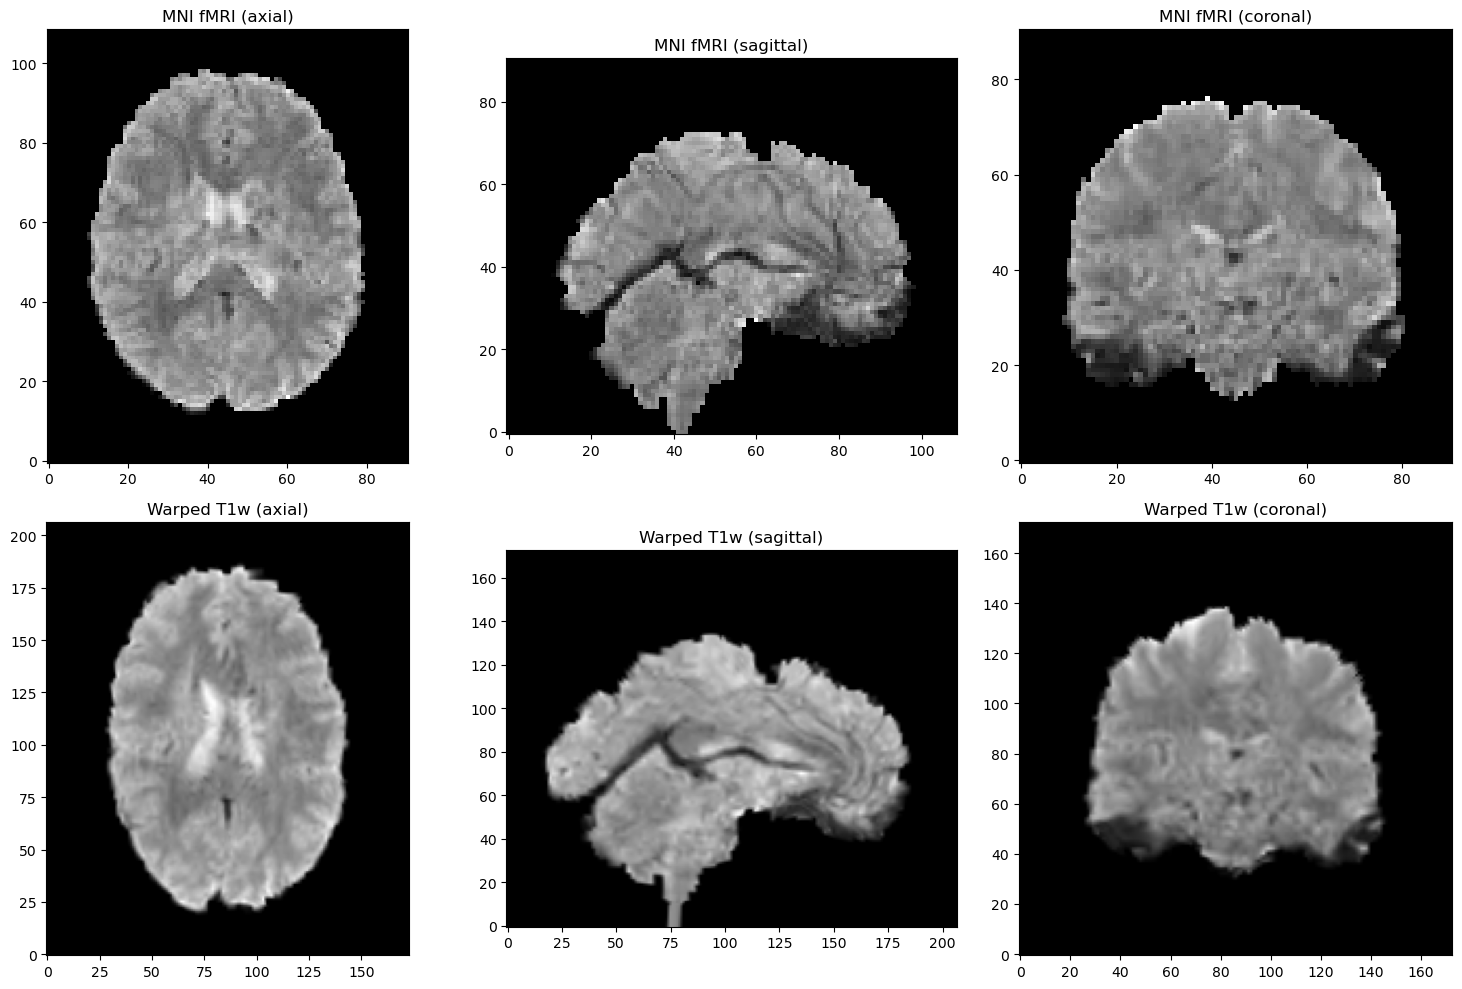

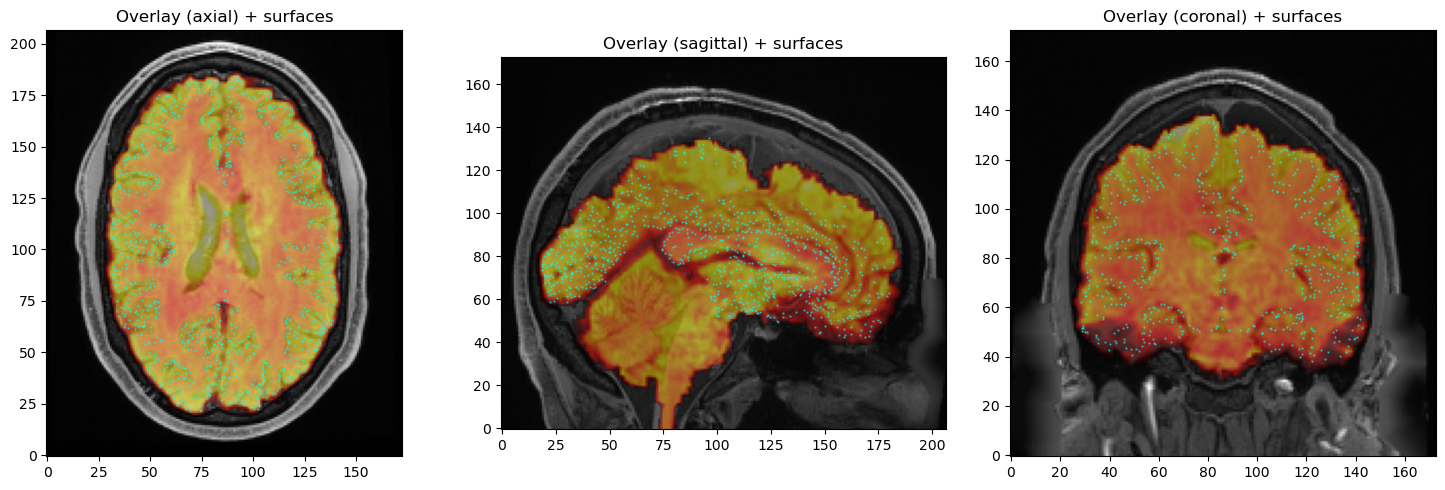

In [6]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from fsl.transform import fnirt
from fsl.data import image as fslimage

print("="*60)
print("APPLYING FNIRT WARP USING FSLPY")
print("="*60)

print("\n1. Loading images...")
# Load with nibabel first to get first timepoint
fmri_nib = nib.load(f"/Users/marcoaqil/Downloads/{sjnr}/MNINonLinear/Results/rfMRI_REST1_RL/rfMRI_REST1_RL_hp2000_clean_rclean_tclean.nii.gz")
fmri_data = fmri_nib.get_fdata()[:, :, :, 0]

# Save first timepoint temporarily
fmri_first_nib = nib.Nifti1Image(fmri_data, fmri_nib.affine, fmri_nib.header)
nib.save(fmri_first_nib, f"/Users/marcoaqil/Downloads/{sjnr}/temp_fmri_t0.nii.gz")

# Load with fslpy Image
fmri_first = fslimage.Image(f"/Users/marcoaqil/Downloads/{sjnr}/temp_fmri_t0.nii.gz")

try:
    ref_img = fslimage.Image(f"/Users/marcoaqil/Downloads/{sjnr}/T1w/T1w_acpc_dc_restore_1.05.nii.gz")
except:
    ref_img = fslimage.Image(f"/Users/marcoaqil/Downloads/{sjnr}/T1w/T1w_acpc_dc_restore_1.25.nii.gz")


print("\n2. Loading warp field...")
warp = fnirt.readFnirt(
    f"/Users/marcoaqil/Downloads/{sjnr}/MNINonLinear/xfms/standard2acpc_dc.nii.gz",
    src=fmri_first,
    ref=ref_img
)

print(f"Warp type: {type(warp)}")
print(f"Warp shape: {warp.shape}")

print("\n3. Applying warp transformation...")
# Apply the warp
from fsl.transform.nonlinear import applyDeformation

warped = applyDeformation(
    fmri_first,
    warp,
    ref=ref_img,
    order=1
)

# Get numpy arrays for visualization
warped_data = np.asarray(warped.data)
t1w_data = np.asarray(ref_img.data)

print("\n4. Loading surfaces...")
lh_surf = nib.load(f"/Users/marcoaqil/Downloads/{sjnr}/T1w/Native/{sjnr}.L.midthickness.downsampled.surf.gii")
rh_surf = nib.load(f"/Users/marcoaqil/Downloads/{sjnr}/T1w/Native/{sjnr}.R.midthickness.downsampled.surf.gii")
vertices_t1w = np.vstack([lh_surf.darrays[0].data, rh_surf.darrays[0].data])

# Convert surface vertices (in T1w RAS mm) to T1w voxel coordinates

try:
    t1w_affine_nib = nib.load(f"/Users/marcoaqil/Downloads/{sjnr}/T1w/T1w_acpc_dc_restore_1.05.nii.gz")
except:
    t1w_affine_nib = nib.load(f"/Users/marcoaqil/Downloads/{sjnr}/T1w/T1w_acpc_dc_restore_1.25.nii.gz")

t1w_inv_affine = np.linalg.inv(t1w_affine_nib.affine)
vertices_vox = nib.affines.apply_affine(t1w_inv_affine, vertices_t1w)

print(f"Loaded {len(vertices_t1w)} vertices")
print(f"Vertex voxel range: X=[{vertices_vox[:, 0].min():.1f}, {vertices_vox[:, 0].max():.1f}], "
      f"Y=[{vertices_vox[:, 1].min():.1f}, {vertices_vox[:, 1].max():.1f}], "
      f"Z=[{vertices_vox[:, 2].min():.1f}, {vertices_vox[:, 2].max():.1f}]")

print(f"\nWarped shape: {warped_data.shape}")
print(f"Non-zero voxels: {np.sum(warped_data != 0)}/{np.prod(warped_data.shape)}")
print(f"Coverage: {100*np.sum(warped_data != 0)/np.prod(warped_data.shape):.1f}%")

print("\n5. Visualizing...")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# MNI
axes[0,0].imshow(fmri_data[:, :, 45].T, origin='lower', cmap='gray')
axes[0,0].set_title('MNI fMRI (axial)')
axes[0,1].imshow(fmri_data[45, :, :].T, origin='lower', cmap='gray')
axes[0,1].set_title('MNI fMRI (sagittal)')
axes[0,2].imshow(fmri_data[:, 54, :].T, origin='lower', cmap='gray')
axes[0,2].set_title('MNI fMRI (coronal)')

# Warped
axes[1,0].imshow(warped_data[:, :, 86].T, origin='lower', cmap='gray')
axes[1,0].set_title('Warped T1w (axial)')
axes[1,1].imshow(warped_data[86, :, :].T, origin='lower', cmap='gray')
axes[1,1].set_title('Warped T1w (sagittal)')
axes[1,2].imshow(warped_data[:, 103, :].T, origin='lower', cmap='gray')
axes[1,2].set_title('Warped T1w (coronal)')

plt.tight_layout()
plt.savefig(f"/Users/marcoaqil/Downloads/{sjnr}/warp_fslpy.png", dpi=150)
print("Saved: warp_fslpy.png")

# Overlay
print("\n6. Creating overlay with surfaces...")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Axial
axes[0].imshow(t1w_data[:, :, 86].T, origin='lower', cmap='gray')
axes[0].imshow(np.ma.masked_where(warped_data[:, :, 86] == 0, warped_data[:, :, 86]).T,
               origin='lower', cmap='hot', alpha=0.5)
# Plot vertices that are near this slice
slice_verts = vertices_vox[(vertices_vox[:, 2] > 84) & (vertices_vox[:, 2] < 88)]
axes[0].scatter(slice_verts[:, 0], slice_verts[:, 1], c='cyan', s=0.5, alpha=0.5)
axes[0].set_title('Overlay (axial) + surfaces')

# Sagittal
axes[1].imshow(t1w_data[86, :, :].T, origin='lower', cmap='gray')
axes[1].imshow(np.ma.masked_where(warped_data[86, :, :] == 0, warped_data[86, :, :]).T,
               origin='lower', cmap='hot', alpha=0.5)
slice_verts = vertices_vox[(vertices_vox[:, 0] > 84) & (vertices_vox[:, 0] < 88)]
axes[1].scatter(slice_verts[:, 1], slice_verts[:, 2], c='cyan', s=0.5, alpha=0.5)
axes[1].set_title('Overlay (sagittal) + surfaces')

# Coronal
axes[2].imshow(t1w_data[:, 103, :].T, origin='lower', cmap='gray')
axes[2].imshow(np.ma.masked_where(warped_data[:, 103, :] == 0, warped_data[:, 103, :]).T,
               origin='lower', cmap='hot', alpha=0.5)
slice_verts = vertices_vox[(vertices_vox[:, 1] > 101) & (vertices_vox[:, 1] < 105)]
axes[2].scatter(slice_verts[:, 0], slice_verts[:, 2], c='cyan', s=0.5, alpha=0.5)
axes[2].set_title('Overlay (coronal) + surfaces')

plt.tight_layout()
plt.savefig(f"/Users/marcoaqil/Downloads/{sjnr}/overlay_fslpy_with_surfaces.png", dpi=150)
print("Saved: overlay_fslpy_with_surfaces.png")

# Clean up
import os
os.remove(f"/Users/marcoaqil/Downloads/{sjnr}/temp_fmri_t0.nii.gz")

print("\n" + "="*60)
print("DONE - Check if overlay shows proper alignment!")
print("="*60)

In [3]:
import numpy as np
import nibabel as nib
from scipy.ndimage import map_coordinates
import os
from joblib import Parallel, delayed
import gc

# ==================== CONFIGURATION ====================
runs = [
    "rfMRI_REST1_RL",
    "rfMRI_REST1_LR",
    "rfMRI_REST2_RL",
    "rfMRI_REST2_LR"
]

n_jobs = 14

# ==================== PROCESS EACH RUN ====================
for run_name in runs:
    print(f"\n{'='*60}")
    print(f"Processing {run_name}")
    print('='*60)
    
    fmri_file = f"/Users/marcoaqil/Downloads/{sjnr}/MNINonLinear/Results/{run_name}/{run_name}_hp2000_clean_rclean_tclean.nii.gz"
    
    if not os.path.exists(fmri_file):
        print(f"WARNING: File not found: {fmri_file}")
        continue
    
    # ==================== STAGE 1: PARALLEL WARPING ====================
    print(f"\n1. STAGE 1: Warping fMRI from MNI to T1w space (PARALLEL)")
    
    # Load and extract all timepoints
    fmri_nib = nib.load(fmri_file)
    fmri_data = fmri_nib.get_fdata().astype(np.float32)
    n_timepoints = fmri_data.shape[3]
    print(f"   Total timepoints: {n_timepoints}")
    
    # Create temp directories
    os.makedirs(f"/Users/marcoaqil/Downloads/{sjnr}/temp_warp", exist_ok=True)
    os.makedirs(f"/Users/marcoaqil/Downloads/{sjnr}/temp_mni", exist_ok=True)
    
    # Extract all MNI timepoints to disk first
    print(f"   Extracting MNI timepoints to disk...")
    for t in range(n_timepoints):
        tp_img = nib.Nifti1Image(fmri_data[:, :, :, t], fmri_nib.affine, fmri_nib.header)
        nib.save(tp_img, f"/Users/marcoaqil/Downloads/{sjnr}/temp_mni/tp_{t}.nii.gz")
        if (t + 1) % 200 == 0:
            print(f"     Extracted {t + 1}/{n_timepoints}")
    
    del fmri_data, fmri_nib
    gc.collect()
    print(f"   ✓ Extracted all timepoints")
    
    # Define warping function
    def warp_preextracted_timepoint(t, run_name):
        """Warp a pre-extracted timepoint"""
        from fsl.data import image as fslimage
        from fsl.transform import fnirt
        from fsl.transform.nonlinear import applyDeformation
        
        # Load pre-extracted MNI timepoint
        temp_in = f"/Users/marcoaqil/Downloads/{sjnr}/temp_mni/tp_{t}.nii.gz"
        src_img = fslimage.Image(temp_in)
        try:
            ref_img = fslimage.Image(f"/Users/marcoaqil/Downloads/{sjnr}/T1w/T1w_acpc_dc_restore_1.05.nii.gz")
        except:
            ref_img = fslimage.Image(f"/Users/marcoaqil/Downloads/{sjnr}/T1w/T1w_acpc_dc_restore_1.25.nii.gz")
        
        # Load warp
        warp = fnirt.readFnirt(f"/Users/marcoaqil/Downloads/{sjnr}/MNINonLinear/xfms/standard2acpc_dc.nii.gz", src=src_img, ref=ref_img)
        
        # Apply warp
        warped = applyDeformation(src_img, warp, ref=ref_img, order=1)
        warped_data = np.asarray(warped.data)
        
        # Save warped data
        output_file = f"/Users/marcoaqil/Downloads/{sjnr}/temp_warp/tp_{run_name}_{t}_warped.npy"
        np.save(output_file, warped_data)
        
        return output_file
    
    # Warp in batches
    batch_size = 400
    warped_files = []
    
    print(f"   Warping {n_timepoints} timepoints using {n_jobs} parallel jobs...")
    print(f"   Processing in batches of {batch_size}")
    
    for batch_start in range(0, n_timepoints, batch_size):
        batch_end = min(batch_start + batch_size, n_timepoints)
        print(f"   Batch {batch_start}-{batch_end}/{n_timepoints}...")
        
        batch_files = Parallel(n_jobs=n_jobs, verbose=5, backend='loky', pre_dispatch='all')(
            delayed(warp_preextracted_timepoint)(t, run_name) for t in range(batch_start, batch_end)
        )
        warped_files.extend(batch_files)
        
        gc.collect()
    
    # Clean up MNI temp files
    print(f"   Cleaning up extracted MNI files...")
    for t in range(n_timepoints):
        os.remove(f"/Users/marcoaqil/Downloads/{sjnr}/temp_mni/tp_{t}.nii.gz")
    os.rmdir(f"/Users/marcoaqil/Downloads/{sjnr}/temp_mni")
    
    print(f"   ✓ All {n_timepoints} timepoints warped and saved to disk")
    
    # ==================== STAGE 2: LOAD AND COMBINE WARPED DATA ====================
    print(f"\n2. STAGE 2: Loading warped timepoints into single array")
    
    # Load first to get shape
    first_warped = np.load(warped_files[0])
    t1w_shape = first_warped.shape
    
    # Pre-allocate
    fmri_t1w_data = np.zeros((*t1w_shape, n_timepoints), dtype=np.float32)
    fmri_t1w_data[..., 0] = first_warped
    
    # Load rest
    print(f"   Loading {n_timepoints} warped volumes...")
    for t in range(1, n_timepoints):
        fmri_t1w_data[..., t] = np.load(warped_files[t])
        if (t + 1) % 200 == 0:
            print(f"     Loaded {t + 1}/{n_timepoints}")
    
    print(f"   Warped fMRI shape: {fmri_t1w_data.shape}")
    
    # Clean up warped temp files
    print(f"   Cleaning up temp warped files...")
    for f in warped_files:
        os.remove(f)
    
    gc.collect()
    
    # ==================== STAGE 3: LOAD SURFACES ====================
    print(f"\n3. STAGE 3: Loading surfaces")
    
    lh_surf = nib.load(f"/Users/marcoaqil/Downloads/{sjnr}/T1w/Native/{sjnr}.L.midthickness.downsampled.surf.gii")
    rh_surf = nib.load(f"/Users/marcoaqil/Downloads/{sjnr}/T1w/Native/{sjnr}.R.midthickness.downsampled.surf.gii")
    lh_vertices_t1w = lh_surf.darrays[0].data
    rh_vertices_t1w = rh_surf.darrays[0].data
    all_vertices_t1w = np.vstack([lh_vertices_t1w, rh_vertices_t1w])
    n_lh = len(lh_vertices_t1w)
    
    print(f"   Left hemisphere: {n_lh} vertices")
    print(f"   Right hemisphere: {len(rh_vertices_t1w)} vertices")
    print(f"   Total: {len(all_vertices_t1w)} vertices")
    
    # Convert to voxel coordinates
    try:
        t1w_nib = nib.load(f"/Users/marcoaqil/Downloads/{sjnr}/T1w/T1w_acpc_dc_restore_1.05.nii.gz")
    except:
        t1w_nib = nib.load(f"/Users/marcoaqil/Downloads/{sjnr}/T1w/T1w_acpc_dc_restore_1.25.nii.gz")
        
    t1w_inv_affine = np.linalg.inv(t1w_nib.affine)
    vertices_vox = nib.affines.apply_affine(t1w_inv_affine, all_vertices_t1w)
    
    # ==================== STAGE 4: PARALLEL PROJECTION TO SURFACE ====================
    print(f"\n4. STAGE 4: Projecting to surface (PARALLEL)")
    print("   Using trilinear interpolation at midthickness surface")
    
    def sample_vertex_batch(vertex_indices):
        """Sample fMRI timeseries at multiple vertices"""
        timeseries = np.zeros((len(vertex_indices), n_timepoints), dtype=np.float32)
        
        for idx, vertex_idx in enumerate(vertex_indices):
            vertex_vox = vertices_vox[vertex_idx]
            
            # Check bounds
            if (vertex_vox[0] >= 0 and vertex_vox[0] < t1w_shape[0] - 1 and
                vertex_vox[1] >= 0 and vertex_vox[1] < t1w_shape[1] - 1 and
                vertex_vox[2] >= 0 and vertex_vox[2] < t1w_shape[2] - 1):
                
                # Coordinates for all timepoints
                coords = np.array([
                    [vertex_vox[0]] * n_timepoints,
                    [vertex_vox[1]] * n_timepoints,
                    [vertex_vox[2]] * n_timepoints,
                    np.arange(n_timepoints)
                ])
                
                timeseries[idx] = map_coordinates(fmri_t1w_data, coords, order=1, mode='constant', cval=0.0)
        
        return timeseries
    
    # Split vertices into batches
    n_vertices = len(vertices_vox)
    vertex_batch_size = 1000
    vertex_batches = [list(range(i, min(i + vertex_batch_size, n_vertices))) 
                     for i in range(0, n_vertices, vertex_batch_size)]
    
    print(f"   Sampling at {n_vertices} vertices in {len(vertex_batches)} batches using {n_jobs} jobs...")
    
    # Parallel sampling
    batch_results = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(sample_vertex_batch)(batch) for batch in vertex_batches
    )
    
    # Concatenate
    all_timeseries = np.vstack(batch_results)
    lh_timeseries = all_timeseries[:n_lh]
    rh_timeseries = all_timeseries[n_lh:]
    
    print(f"   ✓ Projected timeseries shape: {all_timeseries.shape}")
    
    # Free volume data
    del fmri_t1w_data
    gc.collect()
    
    # ==================== SAVE RESULTS ====================
    print(f"\n5. Saving results...")
    output_dir = f"/Users/marcoaqil/Downloads/{sjnr}/MNINonLinear/Results"
    os.makedirs(output_dir, exist_ok=True)
    
    np.save(f"{output_dir}/surface_fmri_timeseries_{run_name}.npy", all_timeseries)
    np.save(f"{output_dir}/lh_fmri_timeseries_{run_name}.npy", lh_timeseries)
    np.save(f"{output_dir}/rh_fmri_timeseries_{run_name}.npy", rh_timeseries)
    
    print(f"   ✓ Saved timeseries for {run_name}")
    
    # ==================== QUALITY CHECK ====================
    print(f"\n6. Quality Check")
    print(f"   Statistics:")
    print(f"     Mean: {np.mean(all_timeseries):.2f}")
    print(f"     Std: {np.std(all_timeseries):.2f}")
    print(f"     Min: {np.min(all_timeseries):.2f}")
    print(f"     Max: {np.max(all_timeseries):.2f}")
    print(f"     NaN count: {np.sum(np.isnan(all_timeseries))}")
    
    zero_vertices = np.sum(np.all(all_timeseries == 0, axis=1))
    low_signal_vertices = np.sum(np.std(all_timeseries, axis=1) < 10)
    print(f"   Vertices with all-zero: {zero_vertices}/{len(all_timeseries)} ({100*zero_vertices/len(all_timeseries):.1f}%)")
    print(f"   Vertices with low signal (std<10): {low_signal_vertices}/{len(all_timeseries)} ({100*low_signal_vertices/len(all_timeseries):.1f}%)")
    
    if zero_vertices > len(all_timeseries) * 0.1:
        print(f"\n   ⚠ WARNING: >10% of vertices have zero signal")
    else:
        print(f"\n   ✓ Projection looks good!")
    
    # Clean up
    del all_timeseries, lh_timeseries, rh_timeseries, all_vertices_t1w
    gc.collect()

# ==================== FINAL CLEANUP ====================
print(f"\n{'='*60}")
print("Final cleanup...")
try:
    os.rmdir(f"/Users/marcoaqil/Downloads/{sjnr}/temp_warp")
except:
    pass

# Save vertex coordinates (load surfaces one more time)
lh_surf = nib.load(f"/Users/marcoaqil/Downloads/{sjnr}/T1w/Native/{sjnr}.L.midthickness.downsampled.surf.gii")
rh_surf = nib.load(f"/Users/marcoaqil/Downloads/{sjnr}/T1w/Native/{sjnr}.R.midthickness.downsampled.surf.gii")
all_vertices_t1w = np.vstack([lh_surf.darrays[0].data, rh_surf.darrays[0].data])
np.save(f"/Users/marcoaqil/Downloads/{sjnr}/MNINonLinear/Results/surface_vertices_t1w_native.npy", all_vertices_t1w)

print(f"\n{'='*60}")
print("✓ ALL RUNS COMPLETED SUCCESSFULLY")
print(f"{'='*60}")


Processing rfMRI_REST1_RL

1. STAGE 1: Warping fMRI from MNI to T1w space (PARALLEL)
   Total timepoints: 1200
   Extracting MNI timepoints to disk...
     Extracted 200/1200
     Extracted 400/1200
     Extracted 600/1200
     Extracted 800/1200
     Extracted 1000/1200
     Extracted 1200/1200
   ✓ Extracted all timepoints
   Warping 1200 timepoints using 14 parallel jobs...
   Processing in batches of 400
   Batch 0-400/1200...


[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  77 out of 400 | elapsed:   11.7s remaining:   49.2s
/Users/marcoaqil/miniforge3/envs/py313/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=14)]: Done 158 out of 400 | elapsed:   23.0s remaining:   35.3s
[Parallel(n_jobs=14)]: Done 239 out of 400 | elapsed:   34.6s remaining:   23.3s
[Parallel(n_jobs=14)]: Done 320 out of 400 | elapsed:   45.6s remaining:   11.4s
[Parallel(n_jobs=14)]: Done 400 out of 400 | elapsed:   57.5s finished
[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.


   Batch 400-800/1200...


[Parallel(n_jobs=14)]: Done  77 out of 400 | elapsed:   12.5s remaining:   52.3s
[Parallel(n_jobs=14)]: Done 158 out of 400 | elapsed:   24.9s remaining:   38.2s
[Parallel(n_jobs=14)]: Done 239 out of 400 | elapsed:   37.2s remaining:   25.1s
[Parallel(n_jobs=14)]: Done 320 out of 400 | elapsed:   48.1s remaining:   12.0s
[Parallel(n_jobs=14)]: Done 400 out of 400 | elapsed:   59.6s finished
[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.


   Batch 800-1200/1200...


...

   Batch 800-1200/1200...


[Parallel(n_jobs=14)]: Done  77 out of 400 | elapsed:   12.1s remaining:   50.9s
[Parallel(n_jobs=14)]: Done 158 out of 400 | elapsed:   24.2s remaining:   37.1s
[Parallel(n_jobs=14)]: Done 239 out of 400 | elapsed:   35.8s remaining:   24.1s
[Parallel(n_jobs=14)]: Done 320 out of 400 | elapsed:   46.6s remaining:   11.6s
[Parallel(n_jobs=14)]: Done 400 out of 400 | elapsed:   58.1s finished


   Cleaning up extracted MNI files...
   ✓ All 1200 timepoints warped and saved to disk

2. STAGE 2: Loading warped timepoints into single array
   Loading 1200 warped volumes...
     Loaded 200/1200
     Loaded 400/1200
     Loaded 600/1200
     Loaded 800/1200
     Loaded 1000/1200
     Loaded 1200/1200
   Warped fMRI shape: (173, 207, 173, 1200)
   Cleaning up temp warped files...

3. STAGE 3: Loading surfaces
   Left hemisphere: 10555 vertices
   Right hemisphere: 10662 vertices
   Total: 21217 vertices

4. STAGE 4: Projecting to surface (PARALLEL)
   Using trilinear interpolation at midthickness surface
   Sampling at 21217 vertices in 22 batches using 14 jobs...


[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done   5 out of  22 | elapsed:    6.1s remaining:   20.8s
[Parallel(n_jobs=14)]: Done  10 out of  22 | elapsed:    6.1s remaining:    7.4s
[Parallel(n_jobs=14)]: Done  15 out of  22 | elapsed:    6.4s remaining:    3.0s
[Parallel(n_jobs=14)]: Done  20 out of  22 | elapsed:    6.9s remaining:    0.7s
[Parallel(n_jobs=14)]: Done  22 out of  22 | elapsed:    6.9s finished


   ✓ Projected timeseries shape: (21217, 1200)

5. Saving results...
   ✓ Saved timeseries for rfMRI_REST2_LR

6. Quality Check
   Statistics:
     Mean: 11316.70
     Std: 2115.30
     Min: 607.43
     Max: 17318.28
     NaN count: 0
   Vertices with all-zero: 0/21217 (0.0%)
   Vertices with low signal (std<10): 0/21217 (0.0%)

   ✓ Projection looks good!

Final cleanup...

✓ ALL RUNS COMPLETED SUCCESSFULLY


In [20]:
import numpy as np
first_k=1
last_k=10000

eigenvectors = np.load(f"/Users/marcoaqil/Downloads/{sjnr}/eigenvectors.npy")
eigenvalues = np.load(f"/Users/marcoaqil/Downloads/{sjnr}/eigenvalues.npy")

runs = [
    "rfMRI_REST1_RL",
    "rfMRI_REST1_LR",
    "rfMRI_REST2_RL",
    "rfMRI_REST2_LR"
]
empirical_SPS = []

for run_name in runs:
    #zero mean and no global signal
    timecourse = np.load(f"/Users/marcoaqil/Downloads/{sjnr}/MNINonLinear/Results/surface_fmri_timeseries_{run_name}.npy")


    tc_nomean = timecourse-timecourse.mean(1)[...,np.newaxis]
    coeffs = np.dot(eigenvectors.T,(tc_nomean-tc_nomean.mean(0)[np.newaxis,...]))
    this_SPS = ((np.abs(coeffs)**2).mean(1)[first_k:last_k])
    empirical_SPS.append(this_SPS)

empirical_SPS = np.mean(empirical_SPS,axis=0)

#the Laplace coefficient of the z-scored timecourses
#coeffs_zscore = np.dot(eigenvectors.T,np.nan_to_num(sp.stats.zscore(timecourse, axis=1)))

#here i define logspace binning
bins = np.unique(np.logspace(np.log10(first_k), np.log10(last_k), num=300, dtype=int))[:-1]
bins_positions = np.array([elem.mean() for elem in np.array_split(np.arange(first_k,last_k), bins)])
def median_binning(data,bins):
    return np.array([np.median(elem) for elem in np.array_split(data, bins)])

In [21]:
import scipy as sp
#empirical_SPS_errors = np.abs(np.dot(eigenvectors.T,errors)).mean(1)

#keep the [:-1] to avoid empty slice problems
bins = np.unique(np.logspace(np.log10(first_k), np.log10(last_k), num=300, dtype=int))[:-1]
binned_SPS = np.array([np.median(elem) for elem in np.array_split(empirical_SPS, bins)])
binned_SPS_points = np.array([elem.mean() for elem in np.array_split(np.arange(first_k,last_k), bins)])
binned_SPS_err = np.array([sp.stats.sem(elem) for elem in np.array_split(empirical_SPS, bins)])
len(bins)

/var/folders/q7/_144hn9j53d8r1w3x2_qn3r80000gq/T/ipykernel_65348/2944294053.py:8: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  binned_SPS_err = np.array([sp.stats.sem(elem) for elem in np.array_split(empirical_SPS, bins)])


217

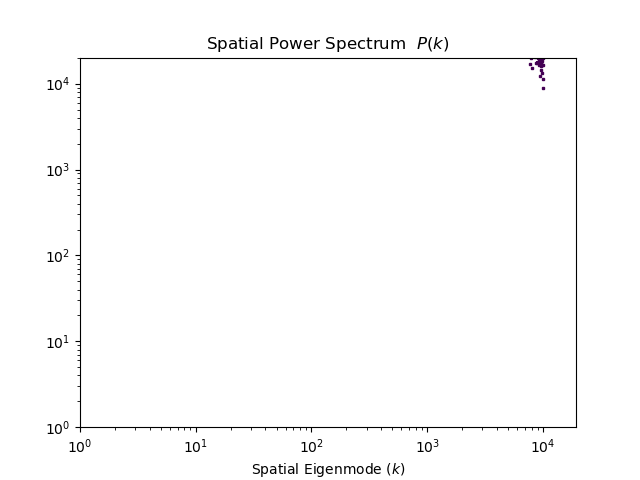

In [22]:
%matplotlib widget
import matplotlib.pyplot as plt

plt.figure()
plt.yscale('log')
plt.xscale('log')
plt.title("Spatial Power Spectrum  $P(k)$")
plt.xlabel("Spatial Eigenmode ($k$)")
#plt.errorbar(x=np.arange(len(empirical_SPS)), y=empirical_SPS, yerr=0, fmt='ks', markersize=1, zorder=1)
plt.errorbar(x=binned_SPS_points, y=binned_SPS, yerr=binned_SPS_err, zorder=2, fmt='yo',markersize=3)

plt.loglog(np.arange(first_k, last_k), empirical_SPS, marker='s', linestyle='', markersize=2, zorder=0, color=[0.267004, 0.004874, 0.329415, 1.])
plot_bins = np.unique(np.logspace(0, np.log10(20000), num=300, dtype=int))[:-1]
y_bins = np.unique(np.logspace(0, np.log10(len(eigenvalues)), num=200, dtype=int))[:-1]
plt.hist2d(np.arange(first_k, last_k), empirical_SPS, (plot_bins, y_bins), cmap='viridis',zorder=1,cmin=2)

fit_to_median=True
if fit_to_median:
    True_Spatial_Spectrum = binned_SPS
    Bins=bins
else:
    True_Spatial_Spectrum = empirical_SPS
    Bins=None
        
LSA=True
Visual=False
SaveFiles=False
FilePath=' '


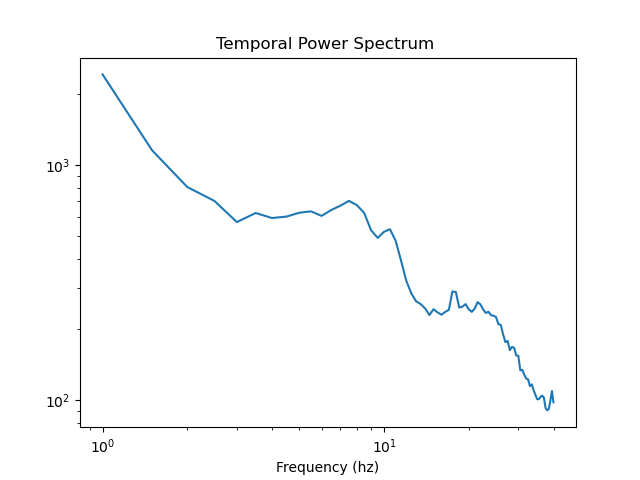

In [23]:
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt

#sjnr = '158136'

fig2 = plt.figure()
ax = fig2.add_subplot(111)
ax.set_title("Temporal Power Spectrum ")
ax.set_xlabel("Frequency (hz)")


meg_hcp_ps_1 = sp.io.loadmat(f'/Users/marcoaqil/Downloads/{sjnr}/MEG/Restin/powavg/{sjnr}_MEG_3-Restin_powavg.mat')
meg_hcp_ps_2 = sp.io.loadmat(f'/Users/marcoaqil/Downloads/{sjnr}/MEG/Restin/powavg/{sjnr}_MEG_4-Restin_powavg.mat')
meg_hcp_ps_3 = sp.io.loadmat(f'/Users/marcoaqil/Downloads/{sjnr}/MEG/Restin/powavg/{sjnr}_MEG_5-Restin_powavg.mat')

meg_hcp_ps_avg = (meg_hcp_ps_1['freq'][0][0][3][0]+meg_hcp_ps_2['freq'][0][0][3][0]+meg_hcp_ps_3['freq'][0][0][3][0])/3.0

meg_hcp_freqs = (meg_hcp_ps_1['freq'][0][0][2][0]>0.99) & (meg_hcp_ps_1['freq'][0][0][2][0]<40)

omegas = meg_hcp_ps_1['freq'][0][0][2][0][meg_hcp_freqs]*2*np.pi

True_Temporal_Spectrum = (2.5*meg_hcp_ps_avg[meg_hcp_freqs]* 10 **30).astype(np.float32)
ax.loglog(meg_hcp_ps_1['freq'][0][0][2][0][meg_hcp_freqs],2.5*meg_hcp_ps_avg[meg_hcp_freqs]* 10 **30)


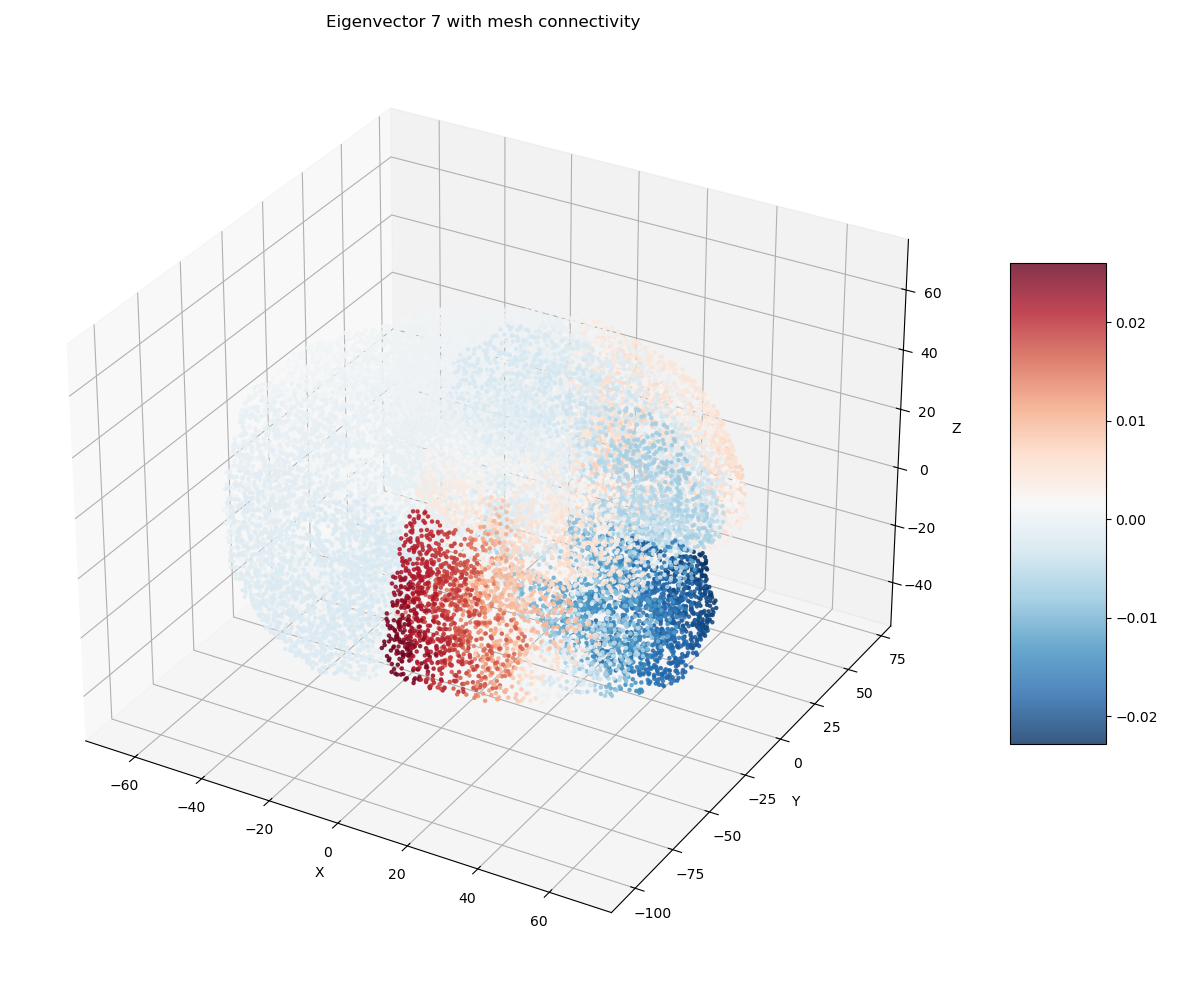

In [ ]:
%matplotlib widget
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load both surfaces
lh_surf = nib.load("T1w/Native/{sjnr}.L.midthickness.downsampled.surf.gii")
rh_surf = nib.load("T1w/Native/{sjnr}.R.midthickness.downsampled.surf.gii")

lh_vertices = lh_surf.darrays[0].data
lh_faces = lh_surf.darrays[1].data
rh_vertices = rh_surf.darrays[0].data
rh_faces = rh_surf.darrays[1].data

n_lh = len(lh_vertices)

# Combine vertices and faces
vertices = np.vstack([lh_vertices, rh_vertices])
faces = np.vstack([lh_faces, rh_faces + n_lh])

# Load your eigenvectors (replace with your actual file/variable)
# eigenvectors shape should be (n_vertices, n_eigenvectors)
# Example: eigenvectors = np.load("your_eigenvectors.npy")

# Visualize a specific eigenvector
eig_idx = 7  # Which eigenvector to plot (0-indexed)
values = eigenvectors[:, eig_idx]

# Create 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot vertices colored by eigenvector values
scatter = ax.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2],
                     c=values, cmap='RdBu_r', s=5, alpha=0.8)

# Plot mesh edges to check connectivity
# print(f"Plotting {len(faces)} triangular faces as edges...")
# for i, face in enumerate(faces):
#     if i % 1000 == 0:
#         print(f"  {i}/{len(faces)}")
#     # Draw the three edges of each triangle
#     for j in range(3):
#         v1 = vertices[face[j]]
#         v2 = vertices[face[(j+1)%3]]
#         ax.plot([v1[0], v2[0]], [v1[1], v2[1]], [v1[2], v2[2]], 
#                 'k-', linewidth=1, alpha=1)

# Add colorbar
fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=5)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'Eigenvector {eig_idx} with mesh connectivity')

plt.tight_layout()
plt.savefig(f'eigenvector_{eig_idx}_with_mesh.png', dpi=150)
plt.show()

IDENTIFYING NON-CORTICAL VERTICES

1. Loading downsampled midthickness surfaces...
  Left hemisphere vertices:  10472
  Right hemisphere vertices: 10269
  Total vertices:            20741

2. Loading aparc.a2009s+aseg volume...
  Aparc volume shape: (260, 311, 260)
  Aparc voxel sizes:  (np.float32(0.7), np.float32(0.7), np.float32(0.7))
  Unique labels:      193

  Vertex voxel coordinate ranges:
    X: [34.9, 221.9]
    Y: [43.8, 272.1]
    Z: [37.9, 199.8]

3. Sampling aparc labels at vertex locations...

4. Classifying vertices...
  Cortical vertices:     20125 (97.0%)
  Non-cortical vertices: 616 (3.0%)

  Left hemi non-cortical:  301 / 10472
  Right hemi non-cortical: 315 / 10269

4b. Cleaning mask — enforcing one contiguous cortex and one contiguous subcortex per hemisphere...

  Left hemisphere:
    --- iteration 1 ---
    non-cortical: 39 components, sizes: [np.int64(236), np.int64(6), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(2), np.int64(2), np.int64(2), n

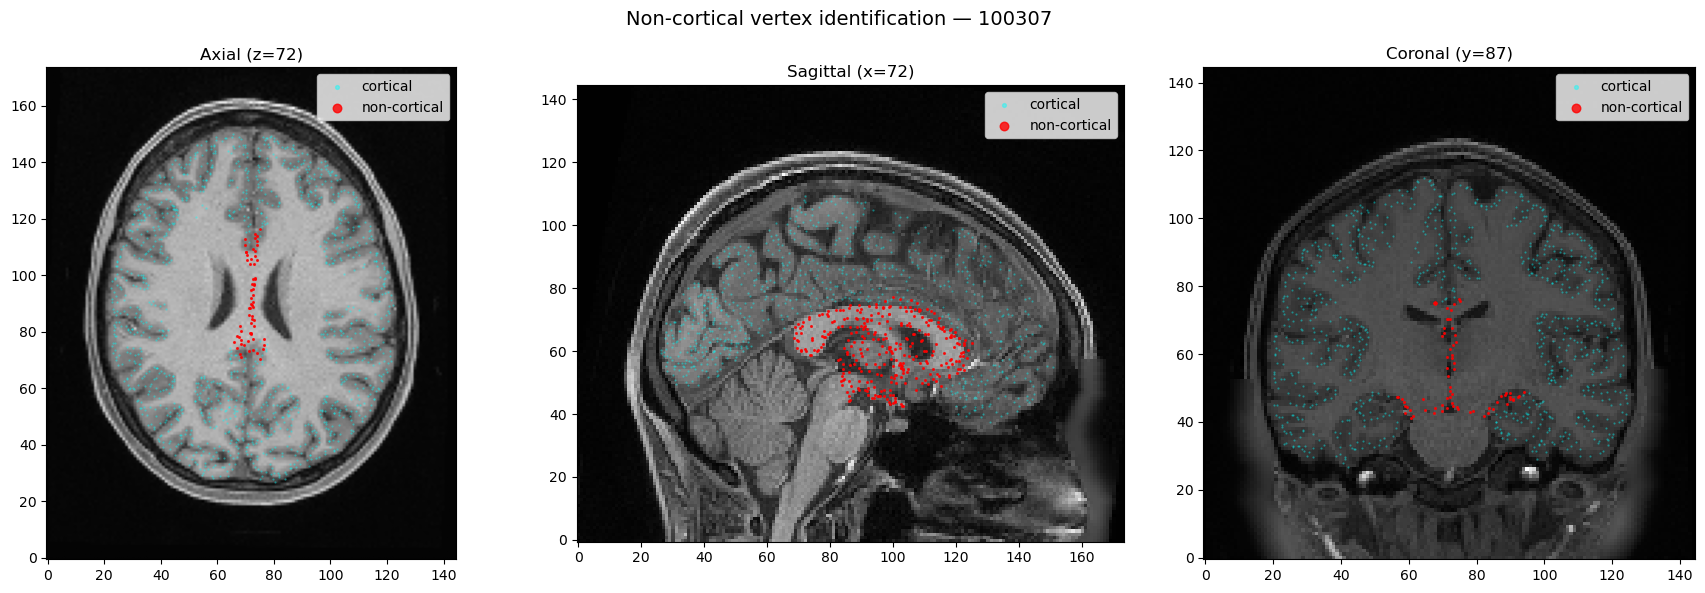

  Saved: /Users/marcoaqil/Desktop/miami_mac/Downloads/100307/T1w/noncortical_vertices_label_histogram.png


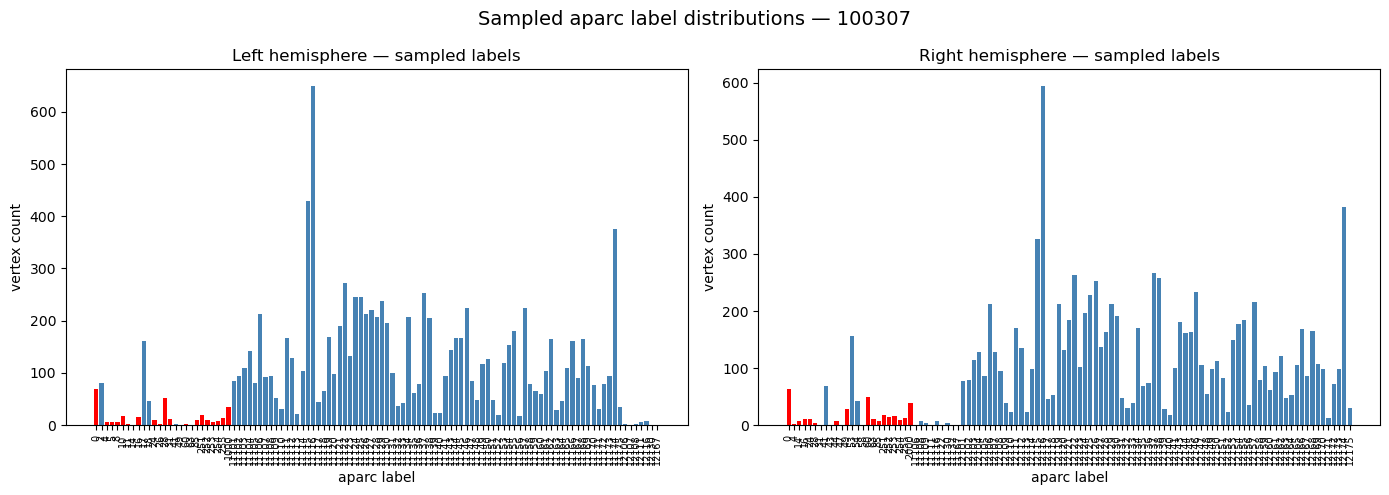


DONE
  Mask saved to: /Users/marcoaqil/Desktop/miami_mac/Downloads/100307/T1w/noncortical_vertex_mask.npz
  Load with: data = np.load('/Users/marcoaqil/Desktop/miami_mac/Downloads/100307/T1w/noncortical_vertex_mask.npz')
  Keys: is_noncortical, is_noncortical_left, is_noncortical_right,
        sampled_aparc_labels, num_left_vertices, num_right_vertices
IDENTIFYING NON-CORTICAL VERTICES

1. Loading downsampled midthickness surfaces...
  Left hemisphere vertices:  10415
  Right hemisphere vertices: 10547
  Total vertices:            20962

2. Loading aparc.a2009s+aseg volume...
  Aparc volume shape: (260, 311, 260)
  Aparc voxel sizes:  (np.float32(0.7), np.float32(0.7), np.float32(0.7))
  Unique labels:      193

  Vertex voxel coordinate ranges:
    X: [36.1, 221.2]
    Y: [40.2, 279.5]
    Z: [44.7, 195.5]

3. Sampling aparc labels at vertex locations...

4. Classifying vertices...
  Cortical vertices:     20391 (97.3%)
  Non-cortical vertices: 571 (2.7%)

  Left hemi non-cortical: 

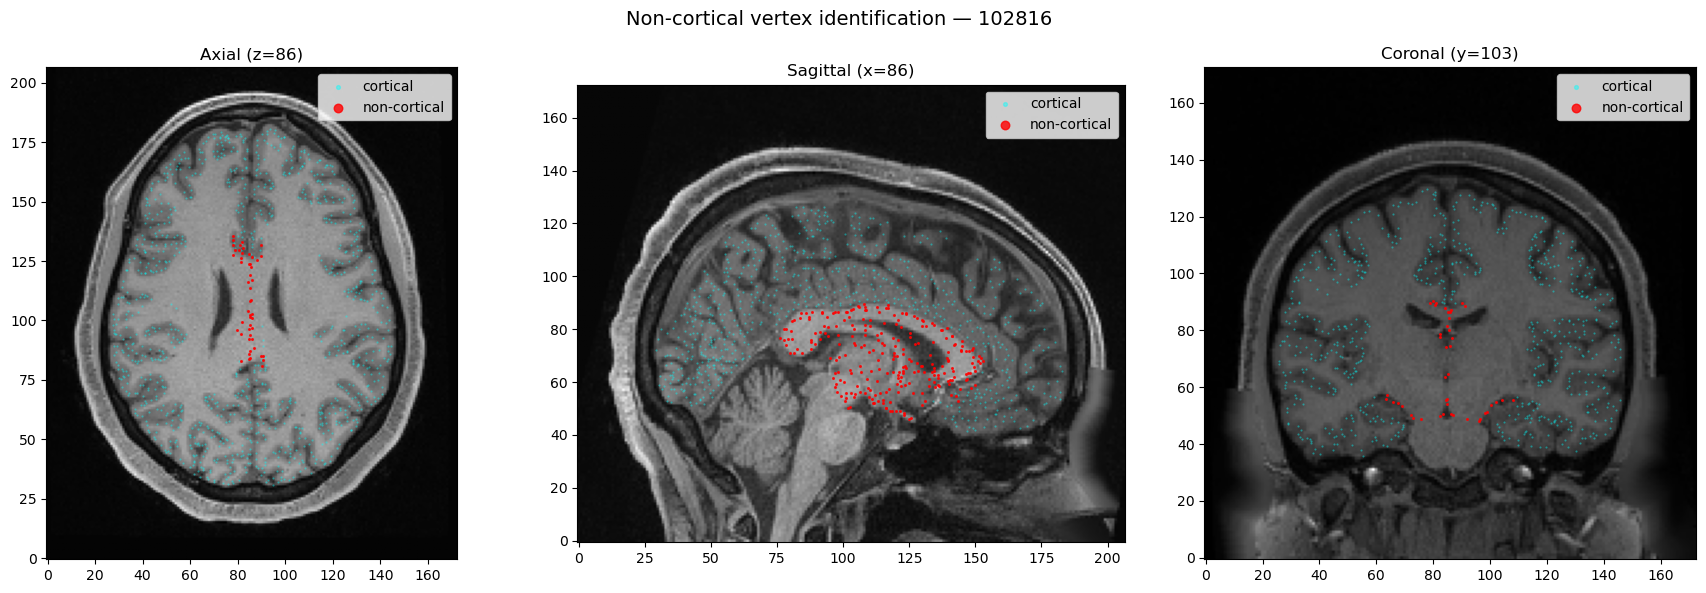

  Saved: /Users/marcoaqil/Desktop/miami_mac/Downloads/102816/T1w/noncortical_vertices_label_histogram.png


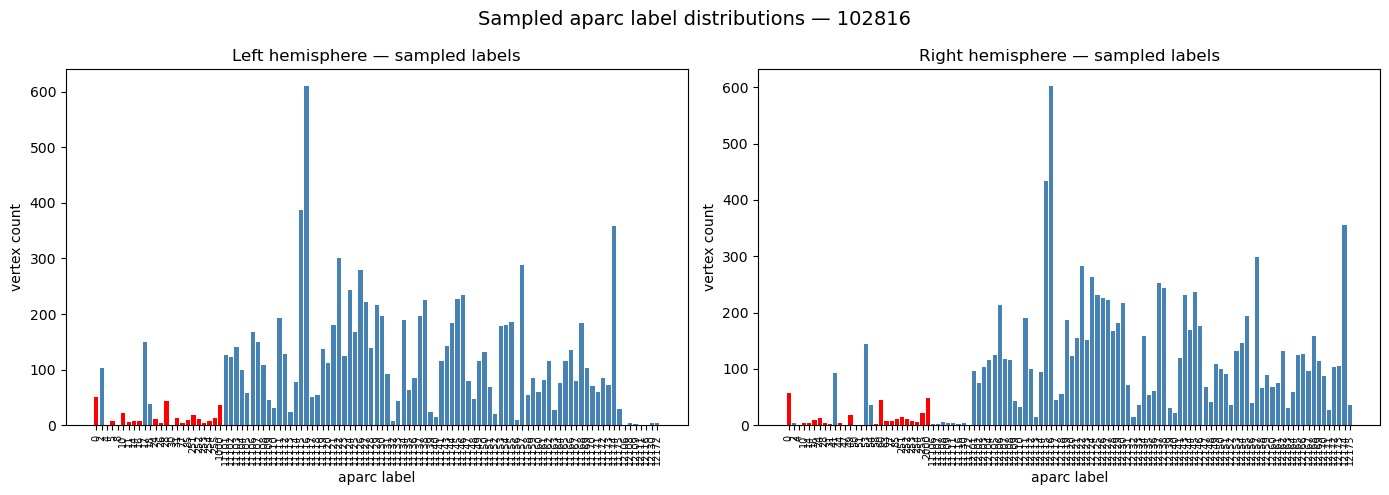


DONE
  Mask saved to: /Users/marcoaqil/Desktop/miami_mac/Downloads/102816/T1w/noncortical_vertex_mask.npz
  Load with: data = np.load('/Users/marcoaqil/Desktop/miami_mac/Downloads/102816/T1w/noncortical_vertex_mask.npz')
  Keys: is_noncortical, is_noncortical_left, is_noncortical_right,
        sampled_aparc_labels, num_left_vertices, num_right_vertices
IDENTIFYING NON-CORTICAL VERTICES

1. Loading downsampled midthickness surfaces...
  Left hemisphere vertices:  10129
  Right hemisphere vertices: 10197
  Total vertices:            20326

2. Loading aparc.a2009s+aseg volume...
  Aparc volume shape: (260, 311, 260)
  Aparc voxel sizes:  (np.float32(0.7), np.float32(0.7), np.float32(0.7))
  Unique labels:      194

  Vertex voxel coordinate ranges:
    X: [32.8, 221.5]
    Y: [35.3, 275.3]
    Z: [39.3, 201.6]

3. Sampling aparc labels at vertex locations...

4. Classifying vertices...
  Cortical vertices:     19778 (97.3%)
  Non-cortical vertices: 548 (2.7%)

  Left hemi non-cortical: 

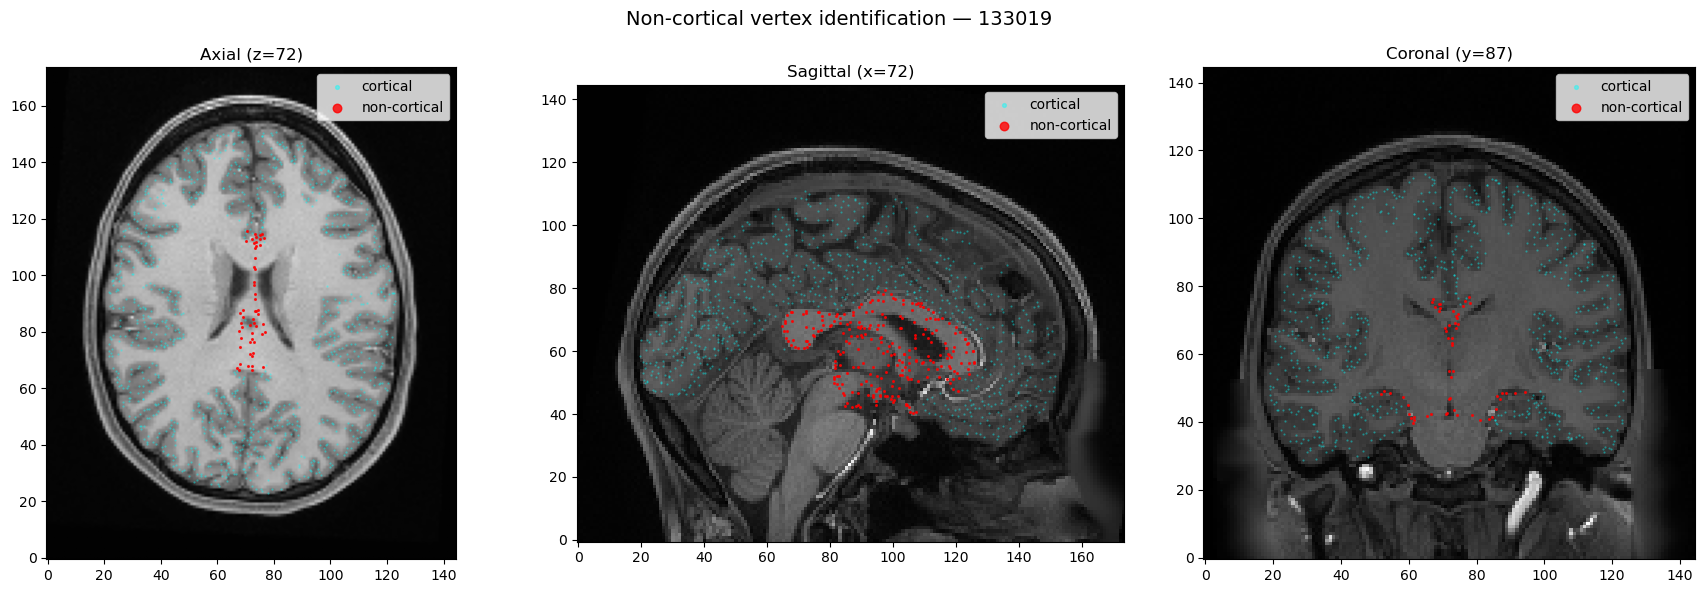

  Saved: /Users/marcoaqil/Desktop/miami_mac/Downloads/133019/T1w/noncortical_vertices_label_histogram.png


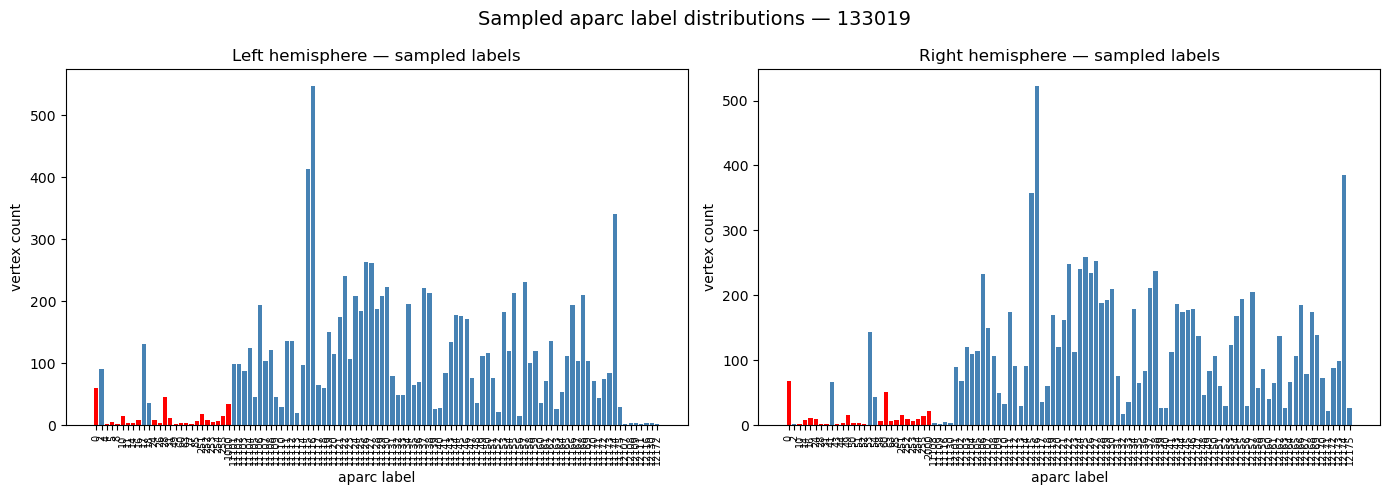


DONE
  Mask saved to: /Users/marcoaqil/Desktop/miami_mac/Downloads/133019/T1w/noncortical_vertex_mask.npz
  Load with: data = np.load('/Users/marcoaqil/Desktop/miami_mac/Downloads/133019/T1w/noncortical_vertex_mask.npz')
  Keys: is_noncortical, is_noncortical_left, is_noncortical_right,
        sampled_aparc_labels, num_left_vertices, num_right_vertices
IDENTIFYING NON-CORTICAL VERTICES

1. Loading downsampled midthickness surfaces...
  Left hemisphere vertices:  10470
  Right hemisphere vertices: 10578
  Total vertices:            21048

2. Loading aparc.a2009s+aseg volume...
  Aparc volume shape: (260, 311, 260)
  Aparc voxel sizes:  (np.float32(0.7), np.float32(0.7), np.float32(0.7))
  Unique labels:      193

  Vertex voxel coordinate ranges:
    X: [26.9, 230.3]
    Y: [35.0, 278.0]
    Z: [60.1, 209.7]

3. Sampling aparc labels at vertex locations...

4. Classifying vertices...
  Cortical vertices:     20477 (97.3%)
  Non-cortical vertices: 571 (2.7%)

  Left hemi non-cortical: 

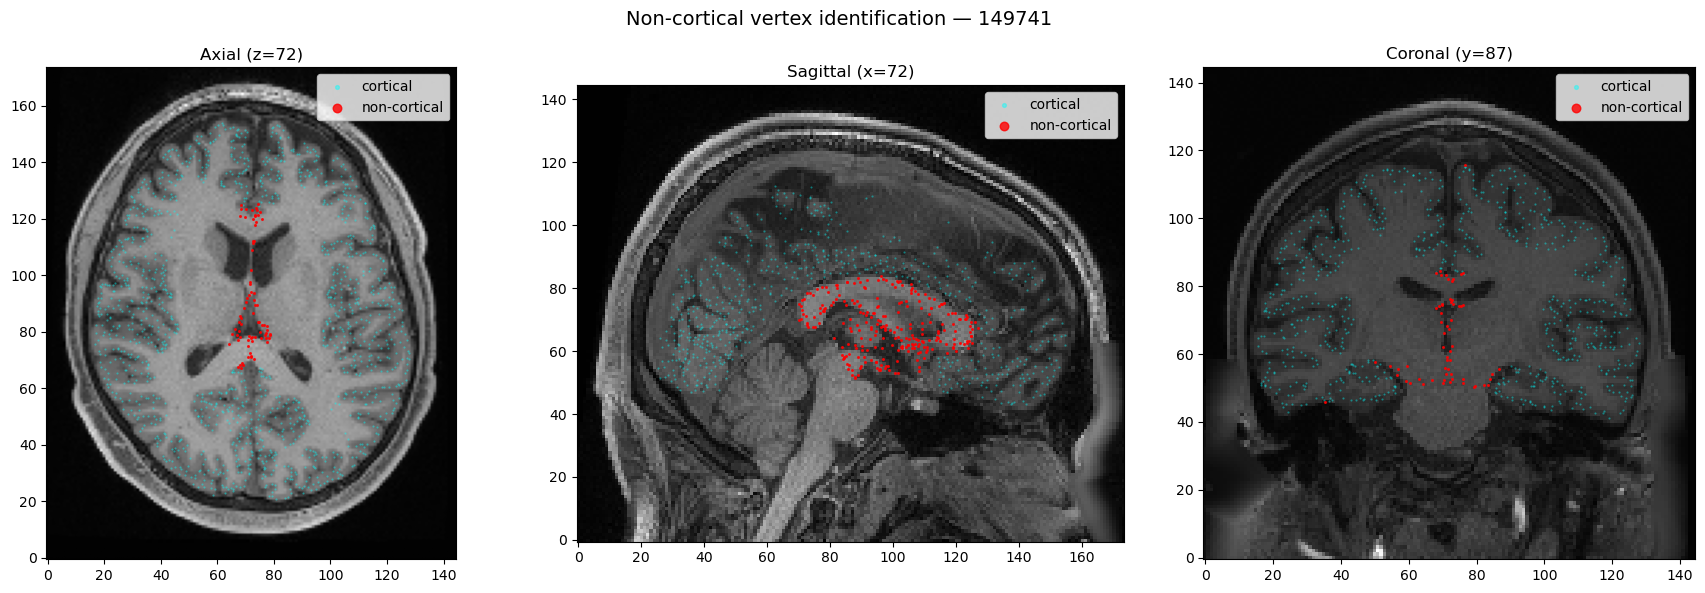

  Saved: /Users/marcoaqil/Desktop/miami_mac/Downloads/149741/T1w/noncortical_vertices_label_histogram.png


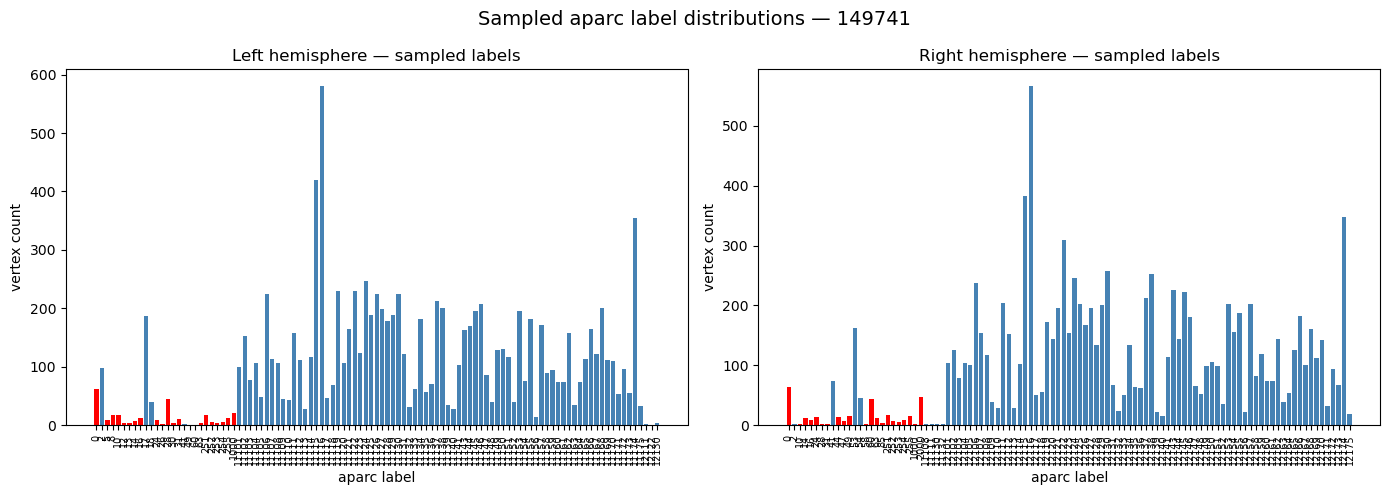


DONE
  Mask saved to: /Users/marcoaqil/Desktop/miami_mac/Downloads/149741/T1w/noncortical_vertex_mask.npz
  Load with: data = np.load('/Users/marcoaqil/Desktop/miami_mac/Downloads/149741/T1w/noncortical_vertex_mask.npz')
  Keys: is_noncortical, is_noncortical_left, is_noncortical_right,
        sampled_aparc_labels, num_left_vertices, num_right_vertices
IDENTIFYING NON-CORTICAL VERTICES

1. Loading downsampled midthickness surfaces...
  Left hemisphere vertices:  10511
  Right hemisphere vertices: 10648
  Total vertices:            21159

2. Loading aparc.a2009s+aseg volume...
  Aparc volume shape: (260, 311, 260)
  Aparc voxel sizes:  (np.float32(0.7), np.float32(0.7), np.float32(0.7))
  Unique labels:      193

  Vertex voxel coordinate ranges:
    X: [36.7, 219.0]
    Y: [36.0, 283.7]
    Z: [42.1, 200.8]

3. Sampling aparc labels at vertex locations...

4. Classifying vertices...
  Cortical vertices:     20649 (97.6%)
  Non-cortical vertices: 510 (2.4%)

  Left hemi non-cortical: 

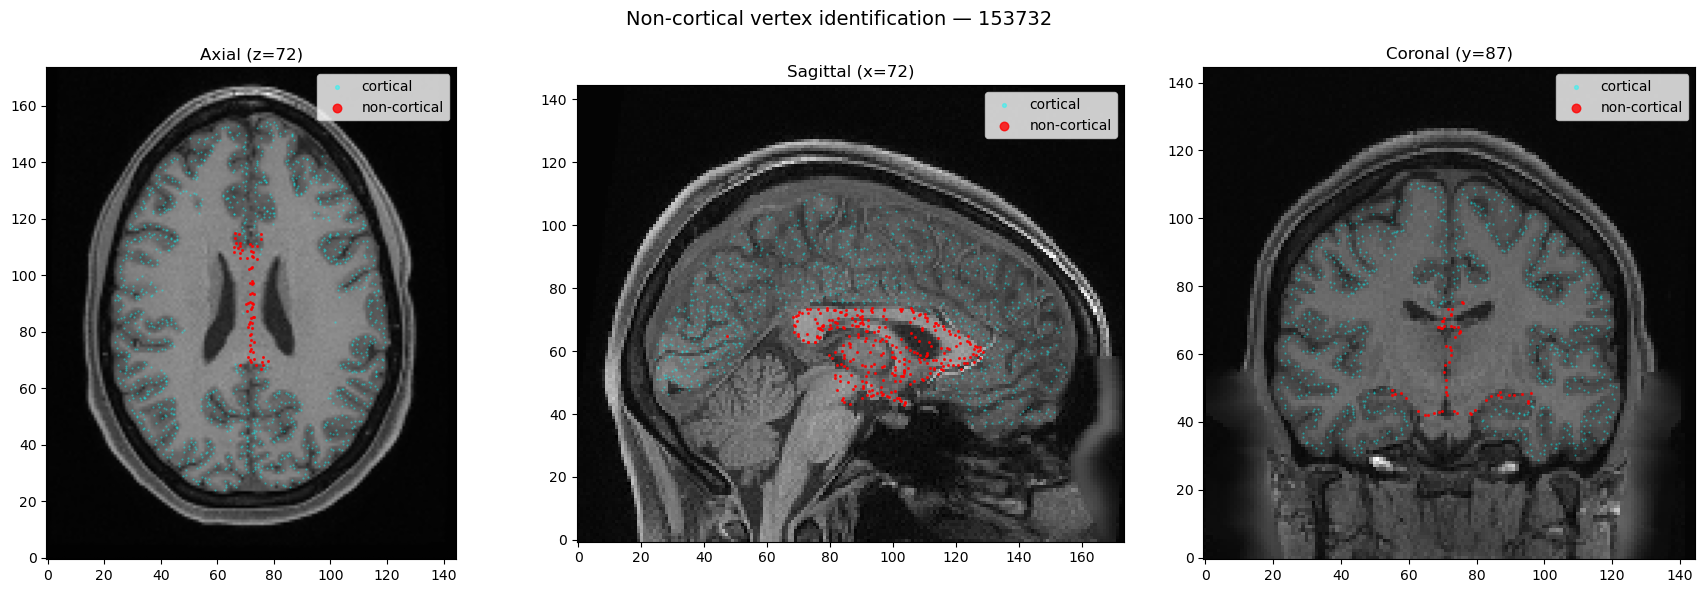

  Saved: /Users/marcoaqil/Desktop/miami_mac/Downloads/153732/T1w/noncortical_vertices_label_histogram.png


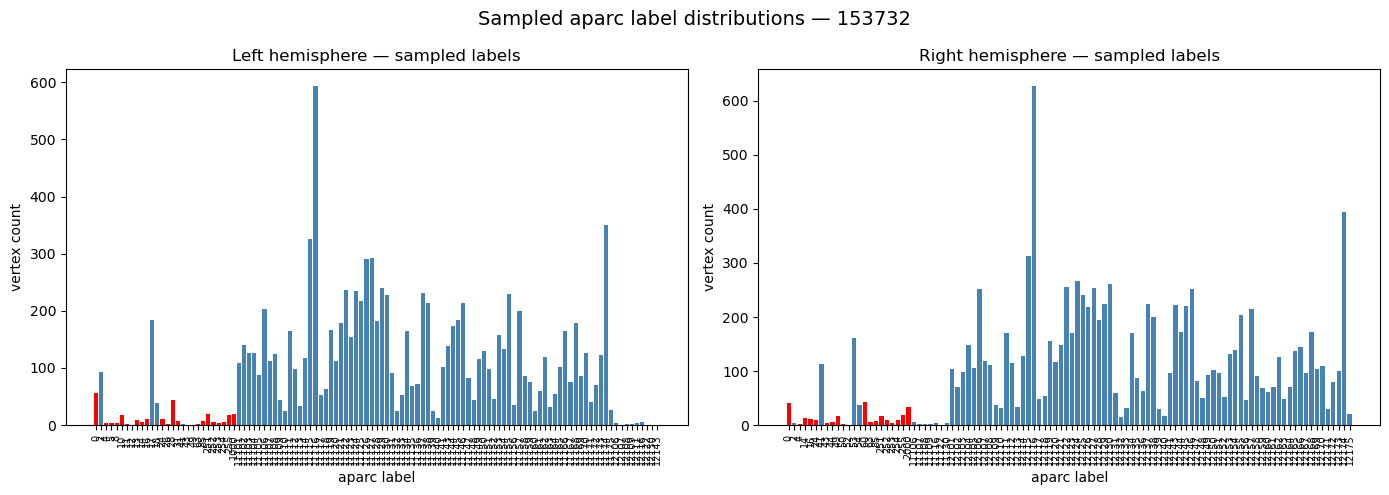


DONE
  Mask saved to: /Users/marcoaqil/Desktop/miami_mac/Downloads/153732/T1w/noncortical_vertex_mask.npz
  Load with: data = np.load('/Users/marcoaqil/Desktop/miami_mac/Downloads/153732/T1w/noncortical_vertex_mask.npz')
  Keys: is_noncortical, is_noncortical_left, is_noncortical_right,
        sampled_aparc_labels, num_left_vertices, num_right_vertices
IDENTIFYING NON-CORTICAL VERTICES

1. Loading downsampled midthickness surfaces...
  Left hemisphere vertices:  10538
  Right hemisphere vertices: 10568
  Total vertices:            21106

2. Loading aparc.a2009s+aseg volume...
  Aparc volume shape: (260, 311, 260)
  Aparc voxel sizes:  (np.float32(0.7), np.float32(0.7), np.float32(0.7))
  Unique labels:      194

  Vertex voxel coordinate ranges:
    X: [39.4, 216.6]
    Y: [14.7, 288.3]
    Z: [39.9, 215.8]

3. Sampling aparc labels at vertex locations...

4. Classifying vertices...
  Cortical vertices:     20575 (97.5%)
  Non-cortical vertices: 531 (2.5%)

  Left hemi non-cortical: 

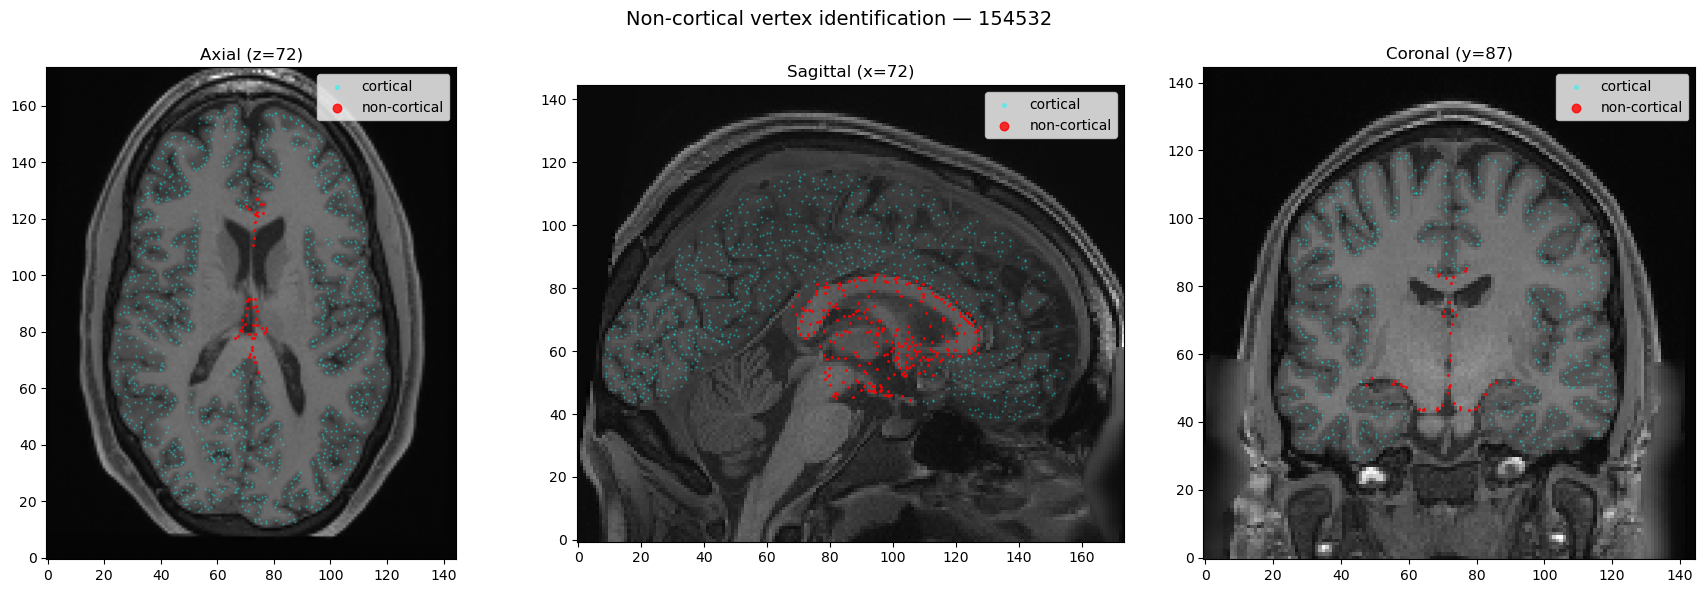

  Saved: /Users/marcoaqil/Desktop/miami_mac/Downloads/154532/T1w/noncortical_vertices_label_histogram.png


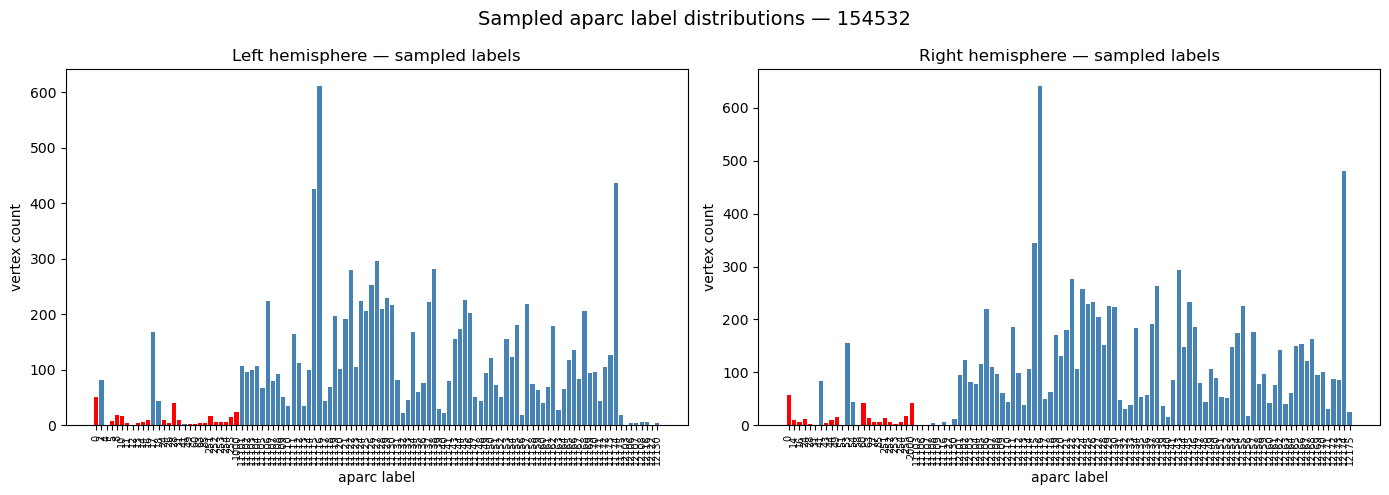


DONE
  Mask saved to: /Users/marcoaqil/Desktop/miami_mac/Downloads/154532/T1w/noncortical_vertex_mask.npz
  Load with: data = np.load('/Users/marcoaqil/Desktop/miami_mac/Downloads/154532/T1w/noncortical_vertex_mask.npz')
  Keys: is_noncortical, is_noncortical_left, is_noncortical_right,
        sampled_aparc_labels, num_left_vertices, num_right_vertices


In [17]:
import numpy as np
import nibabel as nib
from scipy.ndimage import map_coordinates
import matplotlib.pyplot as plt
import os
# ============================================================
# CONFIG
# ============================================================

for subject_id in ['100307', '102816', '133019', '149741', '153732', '154532']:

    base_path = f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{subject_id}"

    # File paths
    aparc_path = f"{base_path}/T1w/aparc.a2009s+aseg.nii.gz"

    if os.path.exists(f"{base_path}/T1w/T1w_acpc_dc_restore_1.25.nii.gz"):
        t1w_path = f"{base_path}/T1w/T1w_acpc_dc_restore_1.25.nii.gz"
    else:
        t1w_path = f"{base_path}/T1w/T1w_acpc_dc_restore_1.05.nii.gz"

    left_surface_path = f"{base_path}/T1w/Native/{subject_id}.L.midthickness.downsampled.surf.gii"
    right_surface_path = f"{base_path}/T1w/Native/{subject_id}.R.midthickness.downsampled.surf.gii"
    output_mask_path = f"{base_path}/T1w/noncortical_vertex_mask.npz"

    # ============================================================
    # 1. LOAD SURFACES
    # ============================================================
    print("=" * 60)
    print("IDENTIFYING NON-CORTICAL VERTICES")
    print("=" * 60)

    print("\n1. Loading downsampled midthickness surfaces...")
    left_surface = nib.load(left_surface_path)
    right_surface = nib.load(right_surface_path)

    left_vertices_ras = left_surface.darrays[0].data
    right_vertices_ras = right_surface.darrays[0].data
    all_vertices_ras = np.vstack([left_vertices_ras, right_vertices_ras])

    num_left_vertices = len(left_vertices_ras)
    num_right_vertices = len(right_vertices_ras)
    num_total_vertices = len(all_vertices_ras)

    print(f"  Left hemisphere vertices:  {num_left_vertices}")
    print(f"  Right hemisphere vertices: {num_right_vertices}")
    print(f"  Total vertices:            {num_total_vertices}")

    # ============================================================
    # 2. LOAD APARC VOLUME AND CONVERT VERTEX COORDS TO VOXELS
    # ============================================================
    print("\n2. Loading aparc.a2009s+aseg volume...")
    aparc_image = nib.load(aparc_path)
    aparc_data = np.asarray(aparc_image.get_fdata(), dtype=np.int32)
    aparc_inverse_affine = np.linalg.inv(aparc_image.affine)

    print(f"  Aparc volume shape: {aparc_data.shape}")
    print(f"  Aparc voxel sizes:  {aparc_image.header.get_zooms()[:3]}")
    print(f"  Unique labels:      {len(np.unique(aparc_data))}")

    # Convert surface vertex RAS coordinates to aparc voxel coordinates
    # (surfaces are in T1w RAS mm space; aparc is also in T1w space)
    vertices_in_aparc_voxels = nib.affines.apply_affine(aparc_inverse_affine, all_vertices_ras)

    print(f"\n  Vertex voxel coordinate ranges:")
    for axis_index, axis_name in enumerate(["X", "Y", "Z"]):
        print(f"    {axis_name}: [{vertices_in_aparc_voxels[:, axis_index].min():.1f}, "
            f"{vertices_in_aparc_voxels[:, axis_index].max():.1f}]")

    # ============================================================
    # 3. SAMPLE APARC LABELS AT EACH VERTEX (NEAREST-NEIGHBOR)
    # ============================================================
    print("\n3. Sampling aparc labels at vertex locations...")

    # Use nearest-neighbor interpolation (order=0) since labels are discrete
    sampled_labels_at_vertices = map_coordinates(
        aparc_data,
        vertices_in_aparc_voxels.T,
        order=0,
        mode='nearest'
    ).astype(np.int32)

    # ============================================================
    # 4. CLASSIFY VERTICES AS CORTICAL VS NON-CORTICAL
    # ============================================================
    print("\n4. Classifying vertices...")

    # FreeSurfer Destrieux (a2009s) + aseg label ranges:
    #   Left cortical parcels:  11101 - 11175
    #   Right cortical parcels: 12101 - 12175
    #   Left generic cortex:    3
    #   Right generic cortex:   42
    #   Left cerebral WM:       2
    #   Right cerebral WM:      41
    #
    # Midthickness surface vertices legitimately pass through both
    # gray matter and white matter, so we treat WM as "cortical" here.
    # Everything else (subcortical nuclei, ventricles, cerebellum,
    # brainstem, background/0) is flagged as non-cortical.

    cortical_label_set = set()

    # Destrieux cortical parcels
    for label in range(11101, 11176):
        cortical_label_set.add(label)
    for label in range(12101, 12176):
        cortical_label_set.add(label)

    # Generic cortex and cerebral white matter
    cortical_label_set.update([2, 3, 41, 42, 17, 53, 18, 54])#[2, 3, 41, 42])

    is_cortical_vertex = np.array(
        [label in cortical_label_set for label in sampled_labels_at_vertices],
        dtype=bool
    )
    is_noncortical_vertex = ~is_cortical_vertex

    num_noncortical = np.sum(is_noncortical_vertex)
    num_cortical = np.sum(is_cortical_vertex)

    print(f"  Cortical vertices:     {num_cortical} ({100 * num_cortical / num_total_vertices:.1f}%)")
    print(f"  Non-cortical vertices: {num_noncortical} ({100 * num_noncortical / num_total_vertices:.1f}%)")

    # Break down by hemisphere
    left_noncortical = is_noncortical_vertex[:num_left_vertices]
    right_noncortical = is_noncortical_vertex[num_left_vertices:]
    print(f"\n  Left hemi non-cortical:  {np.sum(left_noncortical)} / {num_left_vertices}")
    print(f"  Right hemi non-cortical: {np.sum(right_noncortical)} / {num_right_vertices}")

    # ============================================================
    # 4b. CLEAN MASK: ENFORCE SINGLE CONTIGUOUS CORTEX AND SUBCORTEX
    # ============================================================
    from scipy.sparse import lil_matrix
    from scipy.sparse.csgraph import connected_components

    print("\n4b. Cleaning mask — enforcing one contiguous cortex and one contiguous subcortex per hemisphere...")

    def keep_largest_component(vertex_mask, surface_triangles, label):
        """Keep only the largest connected component of True vertices in the mask.
        
        Enforces that there is exactly one contiguous region of the given type
        (cortical or non-cortical) per hemisphere. All smaller components get
        flipped to the opposite classification.
        """
        num_vertices = len(vertex_mask)
        selected_indices = np.where(vertex_mask)[0]
        
        if len(selected_indices) == 0:
            return vertex_mask.copy()
        
        # Map original vertex indices to compact subgraph indices
        original_to_compact = np.full(num_vertices, -1, dtype=np.int64)
        original_to_compact[selected_indices] = np.arange(len(selected_indices))
        
        num_selected = len(selected_indices)
        adjacency = lil_matrix((num_selected, num_selected), dtype=bool)
        
        for triangle in surface_triangles:
            for i in range(3):
                vertex_a = triangle[i]
                vertex_b = triangle[(i + 1) % 3]
                compact_a = original_to_compact[vertex_a]
                compact_b = original_to_compact[vertex_b]
                if compact_a >= 0 and compact_b >= 0:
                    adjacency[compact_a, compact_b] = True
                    adjacency[compact_b, compact_a] = True
        
        num_components, component_labels = connected_components(adjacency.tocsr(), directed=False)
        component_sizes = np.bincount(component_labels)
        largest_component_id = np.argmax(component_sizes)
        
        print(f"    {label}: {num_components} components, sizes: "
            f"{sorted(component_sizes, reverse=True)[:15]}{'...' if num_components > 15 else ''}")
        print(f"    Keeping largest ({component_sizes[largest_component_id]} vertices), "
            f"reclassifying {num_selected - component_sizes[largest_component_id]}")
        
        cleaned_mask = np.zeros(num_vertices, dtype=bool)
        cleaned_mask[selected_indices[component_labels == largest_component_id]] = True
        return cleaned_mask


    def prune_low_triangle_vertices(cortical_mask, surface_triangles, minimum_triangles=2):
        """Iteratively remove cortical vertices that belong to fewer than
        minimum_triangles fully-cortical triangles.
        
        A vertex on a well-formed mesh interior has ~6 triangles. Boundary
        vertices (at the cortex/subcortex cut) have fewer but still >= 2-3.
        A vertex on a flying/dangling triangle connected by a single edge
        belongs to only 1 cortical triangle. Removing it may reduce its
        neighbors' triangle counts, so we iterate until stable.
        """
        cleaned_mask = cortical_mask.copy()
        total_pruned = 0
        iteration = 0
        
        while True:
            iteration += 1
            
            # Count how many fully-cortical triangles each vertex belongs to
            triangle_count_per_vertex = np.zeros(len(cleaned_mask), dtype=np.int32)
            for triangle in surface_triangles:
                if (cleaned_mask[triangle[0]] and
                    cleaned_mask[triangle[1]] and
                    cleaned_mask[triangle[2]]):
                    triangle_count_per_vertex[triangle[0]] += 1
                    triangle_count_per_vertex[triangle[1]] += 1
                    triangle_count_per_vertex[triangle[2]] += 1
            
            # Find cortical vertices with too few triangles
            vertices_to_prune = (
                cleaned_mask &
                (triangle_count_per_vertex > 0) &
                (triangle_count_per_vertex < minimum_triangles)
            )
            num_pruned_this_iteration = np.sum(vertices_to_prune)
            
            if num_pruned_this_iteration == 0:
                break
            
            cleaned_mask[vertices_to_prune] = False
            total_pruned += num_pruned_this_iteration
            print(f"      Prune iteration {iteration}: removed {num_pruned_this_iteration} vertices")
        
        return cleaned_mask, total_pruned


    left_triangles = left_surface.darrays[1].data.astype(np.int64)
    right_triangles = right_surface.darrays[1].data.astype(np.int64)

    for hemisphere_name, noncortical_mask, triangles in [
        ("Left", left_noncortical, left_triangles),
        ("Right", right_noncortical, right_triangles),
    ]:
        print(f"\n  {hemisphere_name} hemisphere:")
        
        # Alternate: clean non-cortical then cortical, until stable.
        # Reclassifying a cortical island as non-cortical could theoretically
        # fragment the non-cortical region, so we iterate until convergence.
        changed = True
        iteration = 0
        while changed:
            iteration += 1
            print(f"    --- iteration {iteration} ---")
            
            new_noncortical = keep_largest_component(noncortical_mask, triangles, "non-cortical")
            new_cortical = keep_largest_component(~new_noncortical, triangles, "cortical")
            # Everything outside the largest cortical component becomes non-cortical
            new_noncortical = ~new_cortical
            
            changed = not np.array_equal(new_noncortical, noncortical_mask)
            noncortical_mask = new_noncortical
        
        print(f"    Converged after {iteration} iteration(s)")
        
        # Prune dangling triangles connected by a single edge
        print(f"    Pruning low-triangle-count vertices...")
        cortical_mask = ~noncortical_mask
        cortical_mask_pruned, num_pruned = prune_low_triangle_vertices(
            cortical_mask, triangles, minimum_triangles=3
        )
        noncortical_mask = ~cortical_mask_pruned
        print(f"    Pruned {num_pruned} dangling vertices total")
        
        if hemisphere_name == "Left":
            left_noncortical = noncortical_mask
        else:
            right_noncortical = noncortical_mask

    # Update combined mask
    is_noncortical_vertex = np.concatenate([left_noncortical, right_noncortical])
    is_cortical_vertex = ~is_noncortical_vertex

    num_noncortical = np.sum(is_noncortical_vertex)
    num_cortical = np.sum(is_cortical_vertex)
    print(f"\n  After cleaning:")
    print(f"    Cortical vertices:     {num_cortical} ({100 * num_cortical / num_total_vertices:.1f}%)")
    print(f"    Non-cortical vertices: {num_noncortical} ({100 * num_noncortical / num_total_vertices:.1f}%)")
    print(f"    Left non-cortical:     {np.sum(left_noncortical)} / {num_left_vertices}")
    print(f"    Right non-cortical:    {np.sum(right_noncortical)} / {num_right_vertices}")

    
    # ============================================================
    # 4c. REMOVE ORPHANS AND RE-ENFORCE CONTIGUITY AFTER PRUNING
    # ============================================================
    print("\n4c. Removing orphans and re-enforcing contiguity after pruning...")

    def remove_orphan_vertices(cortical_mask, surface_triangles):
        """Reclassify cortical vertices that belong to zero fully-cortical
        triangles as non-cortical. Returns cleaned mask and count removed."""
        triangle_count = np.zeros(len(cortical_mask), dtype=np.int32)
        for triangle in surface_triangles:
            if (cortical_mask[triangle[0]] and
                cortical_mask[triangle[1]] and
                cortical_mask[triangle[2]]):
                triangle_count[triangle[0]] += 1
                triangle_count[triangle[1]] += 1
                triangle_count[triangle[2]] += 1
        
        orphans = cortical_mask & (triangle_count == 0)
        cleaned = cortical_mask.copy()
        cleaned[orphans] = False
        return cleaned, np.sum(orphans)


    for hemisphere_name, noncortical_mask, triangles in [
        ("Left", left_noncortical, left_triangles),
        ("Right", right_noncortical, right_triangles),
    ]:
        print(f"\n  {hemisphere_name} hemisphere:")
        
        changed = True
        iteration = 0
        while changed:
            iteration += 1
            print(f"    --- cleanup iteration {iteration} ---")
            
            cortical_mask = ~noncortical_mask
            
            # Remove orphan vertices
            cortical_mask, num_orphans = remove_orphan_vertices(cortical_mask, triangles)
            print(f"    Removed {num_orphans} orphan vertices")
            
            # Re-enforce single contiguous cortex
            cortical_mask = keep_largest_component(cortical_mask, triangles, "cortical")
            
            new_noncortical = ~cortical_mask
            changed = not np.array_equal(new_noncortical, noncortical_mask)
            noncortical_mask = new_noncortical
        
        print(f"    Converged after {iteration} iteration(s)")
        
        if hemisphere_name == "Left":
            left_noncortical = noncortical_mask
        else:
            right_noncortical = noncortical_mask

    # Update combined mask
    is_noncortical_vertex = np.concatenate([left_noncortical, right_noncortical])
    is_cortical_vertex = ~is_noncortical_vertex

    num_noncortical = np.sum(is_noncortical_vertex)
    num_cortical = np.sum(is_cortical_vertex)
    print(f"\n  After cleanup:")
    print(f"    Cortical vertices:     {num_cortical} ({100 * num_cortical / num_total_vertices:.1f}%)")
    print(f"    Non-cortical vertices: {num_noncortical} ({100 * num_noncortical / num_total_vertices:.1f}%)")

    # ============================================================
    # 4d. VERIFY CORTICAL MESH CONNECTIVITY
    # ============================================================
    print("\n4d. Verifying cortical mesh connectivity after all cleaning...")

    for hemisphere_name, noncortical_mask, triangles in [
        ("Left", left_noncortical, left_triangles),
        ("Right", right_noncortical, right_triangles),
    ]:
        cortical_mask = ~noncortical_mask
        cortical_indices = np.where(cortical_mask)[0]
        original_to_compact = np.full(len(cortical_mask), -1, dtype=np.int64)
        original_to_compact[cortical_indices] = np.arange(len(cortical_indices))
        
        num_cortical_verts = len(cortical_indices)
        adjacency = lil_matrix((num_cortical_verts, num_cortical_verts), dtype=bool)
        
        for triangle in triangles:
            if cortical_mask[triangle[0]] and cortical_mask[triangle[1]] and cortical_mask[triangle[2]]:
                for i in range(3):
                    compact_a = original_to_compact[triangle[i]]
                    compact_b = original_to_compact[triangle[(i + 1) % 3]]
                    adjacency[compact_a, compact_b] = True
                    adjacency[compact_b, compact_a] = True
        
        num_components, _ = connected_components(adjacency.tocsr(), directed=False)
        
        triangle_count = np.zeros(len(cortical_mask), dtype=np.int32)
        for triangle in triangles:
            if cortical_mask[triangle[0]] and cortical_mask[triangle[1]] and cortical_mask[triangle[2]]:
                triangle_count[triangle[0]] += 1
                triangle_count[triangle[1]] += 1
                triangle_count[triangle[2]] += 1
        
        orphan_count = np.sum(cortical_mask & (triangle_count == 0))
        cortical_degrees = np.array(adjacency.sum(axis=1)).flatten()
        
        print(f"  {hemisphere_name} hemisphere:")
        print(f"    Connected components: {num_components}")
        print(f"    Orphan vertices (no cortical triangles): {orphan_count}")
        print(f"    Cortical mesh degree: min={cortical_degrees.min():.0f}, "
            f"max={cortical_degrees.max():.0f}, mean={cortical_degrees.mean():.1f}")
        print(f"    Vertices with degree <= 2: {np.sum(cortical_degrees <= 2)}")
        
        if num_components > 1 or orphan_count > 0:
            print(f"    WARNING: mesh is not clean!")
        else:
            print(f"    OK — single connected component, no orphans")

    # ============================================================
    # 5. DIAGNOSTIC: WHICH LABELS DO NON-CORTICAL VERTICES HAVE?
    # ============================================================
    print("\n5. Label breakdown for non-cortical vertices:")

    # FreeSurfer aseg label names (common ones)
    freesurfer_label_names = {
        0: "Unknown/Background",
        2: "Left-Cerebral-White-Matter",
        3: "Left-Cerebral-Cortex",
        4: "Left-Lateral-Ventricle",
        5: "Left-Inf-Lat-Vent",
        7: "Left-Cerebellum-White-Matter",
        8: "Left-Cerebellum-Cortex",
        10: "Left-Thalamus",
        11: "Left-Caudate",
        12: "Left-Putamen",
        13: "Left-Pallidum",
        14: "3rd-Ventricle",
        15: "4th-Ventricle",
        16: "Brain-Stem",
        17: "Left-Hippocampus",
        18: "Left-Amygdala",
        24: "CSF",
        26: "Left-Accumbens-area",
        28: "Left-VentralDC",
        30: "Left-vessel",
        31: "Left-choroid-plexus",
        41: "Right-Cerebral-White-Matter",
        42: "Right-Cerebral-Cortex",
        43: "Right-Lateral-Ventricle",
        44: "Right-Inf-Lat-Vent",
        46: "Right-Cerebellum-White-Matter",
        47: "Right-Cerebellum-Cortex",
        49: "Right-Thalamus",
        50: "Right-Caudate",
        51: "Right-Putamen",
        52: "Right-Pallidum",
        53: "Right-Hippocampus",
        54: "Right-Amygdala",
        58: "Right-Accumbens-area",
        60: "Right-VentralDC",
        62: "Right-vessel",
        63: "Right-choroid-plexus",
        77: "WM-hypointensities",
        85: "Optic-Chiasm",
        251: "CC_Posterior",
        252: "CC_Mid_Posterior",
        253: "CC_Central",
        254: "CC_Mid_Anterior",
        255: "CC_Anterior",
    }

    noncortical_labels = sampled_labels_at_vertices[is_noncortical_vertex]
    unique_noncortical_labels, noncortical_label_counts = np.unique(
        noncortical_labels, return_counts=True
    )

    # Sort by count descending
    sorted_indices = np.argsort(-noncortical_label_counts)
    for index in sorted_indices:
        label = unique_noncortical_labels[index]
        count = noncortical_label_counts[index]
        label_name = freesurfer_label_names.get(label, f"Destrieux/Other ({label})")
        print(f"    Label {label:5d} ({label_name}): {count} vertices")

    # ============================================================
    # 6. SAVE MASK
    # ============================================================
    print(f"\n6. Saving non-cortical vertex mask to:\n   {output_mask_path}")

    np.savez(
        output_mask_path,
        is_noncortical=is_noncortical_vertex,
        is_noncortical_left=left_noncortical,
        is_noncortical_right=right_noncortical,
        sampled_aparc_labels=sampled_labels_at_vertices,
        num_left_vertices=num_left_vertices,
        num_right_vertices=num_right_vertices,
    )

    # ============================================================
    # 7. DIAGNOSTIC PLOTS
    # ============================================================
    print("\n7. Creating diagnostic plots...")

    # --- Plot A: Axial/sagittal/coronal slices with vertices colored by cortical status ---
    t1w_image = nib.load(t1w_path)
    t1w_data = np.asarray(t1w_image.get_fdata())
    t1w_inverse_affine = np.linalg.inv(t1w_image.affine)

    # Convert vertices to T1w voxel coords for plotting on T1w slices
    vertices_in_t1w_voxels = nib.affines.apply_affine(t1w_inverse_affine, all_vertices_ras)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"Non-cortical vertex identification — {subject_id}", fontsize=14)

    # Choose slice indices near the center of the volume
    axial_slice_index = t1w_data.shape[2] // 2
    sagittal_slice_index = t1w_data.shape[0] // 2
    coronal_slice_index = t1w_data.shape[1] // 2

    slice_half_thickness = 2  # voxel half-width for selecting nearby vertices

    # Axial
    axes[0].imshow(t1w_data[:, :, axial_slice_index].T, origin='lower', cmap='gray')
    nearby_axial = np.abs(vertices_in_t1w_voxels[:, 2] - axial_slice_index) < slice_half_thickness
    cortical_nearby_axial = nearby_axial & is_cortical_vertex
    noncortical_nearby_axial = nearby_axial & is_noncortical_vertex
    axes[0].scatter(
        vertices_in_t1w_voxels[cortical_nearby_axial, 0],
        vertices_in_t1w_voxels[cortical_nearby_axial, 1],
        c='cyan', s=0.3, alpha=0.4, label='cortical'
    )
    axes[0].scatter(
        vertices_in_t1w_voxels[noncortical_nearby_axial, 0],
        vertices_in_t1w_voxels[noncortical_nearby_axial, 1],
        c='red', s=1.5, alpha=0.8, label='non-cortical'
    )
    axes[0].set_title(f'Axial (z={axial_slice_index})')
    axes[0].legend(loc='upper right', markerscale=5)

    # Sagittal
    axes[1].imshow(t1w_data[sagittal_slice_index, :, :].T, origin='lower', cmap='gray')
    nearby_sagittal = np.abs(vertices_in_t1w_voxels[:, 0] - sagittal_slice_index) < slice_half_thickness
    cortical_nearby_sagittal = nearby_sagittal & is_cortical_vertex
    noncortical_nearby_sagittal = nearby_sagittal & is_noncortical_vertex
    axes[1].scatter(
        vertices_in_t1w_voxels[cortical_nearby_sagittal, 1],
        vertices_in_t1w_voxels[cortical_nearby_sagittal, 2],
        c='cyan', s=0.3, alpha=0.4, label='cortical'
    )
    axes[1].scatter(
        vertices_in_t1w_voxels[noncortical_nearby_sagittal, 1],
        vertices_in_t1w_voxels[noncortical_nearby_sagittal, 2],
        c='red', s=1.5, alpha=0.8, label='non-cortical'
    )
    axes[1].set_title(f'Sagittal (x={sagittal_slice_index})')
    axes[1].legend(loc='upper right', markerscale=5)

    # Coronal
    axes[2].imshow(t1w_data[:, coronal_slice_index, :].T, origin='lower', cmap='gray')
    nearby_coronal = np.abs(vertices_in_t1w_voxels[:, 1] - coronal_slice_index) < slice_half_thickness
    cortical_nearby_coronal = nearby_coronal & is_cortical_vertex
    noncortical_nearby_coronal = nearby_coronal & is_noncortical_vertex
    axes[2].scatter(
        vertices_in_t1w_voxels[cortical_nearby_coronal, 0],
        vertices_in_t1w_voxels[cortical_nearby_coronal, 2],
        c='cyan', s=0.3, alpha=0.4, label='cortical'
    )
    axes[2].scatter(
        vertices_in_t1w_voxels[noncortical_nearby_coronal, 0],
        vertices_in_t1w_voxels[noncortical_nearby_coronal, 2],
        c='red', s=1.5, alpha=0.8, label='non-cortical'
    )
    axes[2].set_title(f'Coronal (y={coronal_slice_index})')
    axes[2].legend(loc='upper right', markerscale=5)

    plt.tight_layout()
    diagnostic_overlay_path = f"{base_path}/T1w/noncortical_vertices_overlay.png"
    plt.savefig(diagnostic_overlay_path, dpi=150)
    print(f"  Saved: {diagnostic_overlay_path}")
    plt.show()

    # --- Plot B: Histogram of sampled labels ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Sampled aparc label distributions — {subject_id}", fontsize=14)

    # Left hemisphere
    left_labels = sampled_labels_at_vertices[:num_left_vertices]
    unique_left, counts_left = np.unique(left_labels, return_counts=True)
    noncortical_left_mask_for_bars = np.array(
        [label not in cortical_label_set for label in unique_left]
    )
    bar_colors_left = ['red' if is_nc else 'steelblue' for is_nc in noncortical_left_mask_for_bars]
    axes[0].bar(range(len(unique_left)), counts_left, color=bar_colors_left)
    axes[0].set_xticks(range(len(unique_left)))
    axes[0].set_xticklabels(unique_left, rotation=90, fontsize=7)
    axes[0].set_title("Left hemisphere — sampled labels")
    axes[0].set_xlabel("aparc label")
    axes[0].set_ylabel("vertex count")

    # Right hemisphere
    right_labels = sampled_labels_at_vertices[num_left_vertices:]
    unique_right, counts_right = np.unique(right_labels, return_counts=True)
    noncortical_right_mask_for_bars = np.array(
        [label not in cortical_label_set for label in unique_right]
    )
    bar_colors_right = ['red' if is_nc else 'steelblue' for is_nc in noncortical_right_mask_for_bars]
    axes[1].bar(range(len(unique_right)), counts_right, color=bar_colors_right)
    axes[1].set_xticks(range(len(unique_right)))
    axes[1].set_xticklabels(unique_right, rotation=90, fontsize=7)
    axes[1].set_title("Right hemisphere — sampled labels")
    axes[1].set_xlabel("aparc label")
    axes[1].set_ylabel("vertex count")

    plt.tight_layout()
    diagnostic_histogram_path = f"{base_path}/T1w/noncortical_vertices_label_histogram.png"
    plt.savefig(diagnostic_histogram_path, dpi=150)
    print(f"  Saved: {diagnostic_histogram_path}")
    plt.show()

    print("\n" + "=" * 60)
    print("DONE")
    print(f"  Mask saved to: {output_mask_path}")
    print(f"  Load with: data = np.load('{output_mask_path}')")
    print(f"  Keys: is_noncortical, is_noncortical_left, is_noncortical_right,")
    print(f"        sampled_aparc_labels, num_left_vertices, num_right_vertices")
    print("=" * 60)